In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import scienceplots
plt.style.use(['science', 'no-latex'])

from utils import colors

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

IMAGES_PATH = "/Users/klemenkubelj/Documents/school/graduate/masters/code/cvar-masters-thesis-2025/figures"

In [4]:
from utils.flood_request_utils import (
    residential_damage_fractions,
    commercial_damage_function,
    industrial_damage_function,
    agriculture_damage_function,
    residential_damage_fractions_calibrated,
    commercial_damage_function_calibrated,
    industrial_damage_function_calibrated,
    agriculture_damage_function_calibrated,
    get_damage_fraction,
)

In [5]:
plt.rcParams.update({
    'font.size': 14,          # General font size
    'axes.titlesize': 16,     # Title font size
    'axes.labelsize': 14,     # X and Y label font size
    'xtick.labelsize': 14,    # X-axis tick label size
    'ytick.labelsize': 14,    # Y-axis tick label size
    'legend.fontsize': 12,    # Legend font size
    'figure.titlesize': 18,    # Figure title (suptitle) font size

    "axes.axisbelow": True
})

In [6]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [7]:
df = pd.read_csv(os.path.join("../data/vloge_processed_2025-05-10.csv"))
print("Original shape:", df.shape)

# Show number of samples, split by event
event_sample_counts = df["DogodekId"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)
print("Before filtering:", df.shape)

# df["relative_damage"] = df["SkupnaSkoda"] / df["Vrednost"]
df["relative_damage"] = df["OdstPoskodovanostiObjekta"] / 100
df["Objekt_VisinaVodeM"] = df["Objekt_VisinaVodeCm"] / 100
df = df[
    (df["relative_damage"].notna())
    & (df["relative_damage"]<=1)
    & (df["Objekt_VisinaVodeM"].notna())
    # & (df["Objekt_VisinaVodeM"]<=2.5)
    & (df["Objekt_VisinaVodeM"]>=0)
]
# Cap relative damage at 1
df["relative_damage"] = df["relative_damage"].clip(upper=1)
print("--------------------------------")
# Create water height buckets (every 50cm up to 200cm)
# bucket_edges = np.arange(0, 2.01, 0.5)
min_depth = 0
max_depth = 2
bucket_width = 0.5
bucket_edges = np.arange(min_depth, max_depth + 0.1, bucket_width)
print("Bucket edges:")
print(bucket_edges)
df["water_height_bucket"] = pd.cut(
    df["Objekt_VisinaVodeM"], 
    bins=bucket_edges,
    labels=[f"{i}-{i+0.5}m" for i in np.arange(min_depth, max_depth, bucket_width)]
)
print("Number of samples split by water height bucket:")
water_height_sample_counts = df["water_height_bucket"].value_counts()
print(water_height_sample_counts)

print("--------------------------------")
# Set property_type based on "Objekt_VrstaObjektaId"
df["property_type"] = df["Objekt_VrstaObjektaId"].map({
    1: "industrial",
    2: "residential",
    4: "commercial",
    5: "agriculture",
})
# Remove nana values
df = df[df["property_type"].notna()]
print("Number of samples split by property_type:")
property_type_sample_counts = df["property_type"].value_counts()
print(property_type_sample_counts)

print("--------------------------------")
print("After filtering:", df.shape)

Original shape: (20040, 18)
Number of samples split by event:
DogodekId
68    12389
14     3086
18     2415
24     2150
Name: count, dtype: int64
Before filtering: (20040, 18)
--------------------------------
Bucket edges:
[0.  0.5 1.  1.5 2. ]
Number of samples split by water height bucket:
water_height_bucket
0.0-0.5m    1856
0.5-1.0m    1473
1.0-1.5m     827
1.5-2.0m     597
Name: count, dtype: int64
--------------------------------
Number of samples split by property_type:
property_type
residential    3249
agriculture     586
commercial      218
industrial      147
Name: count, dtype: int64
--------------------------------
After filtering: (4200, 22)


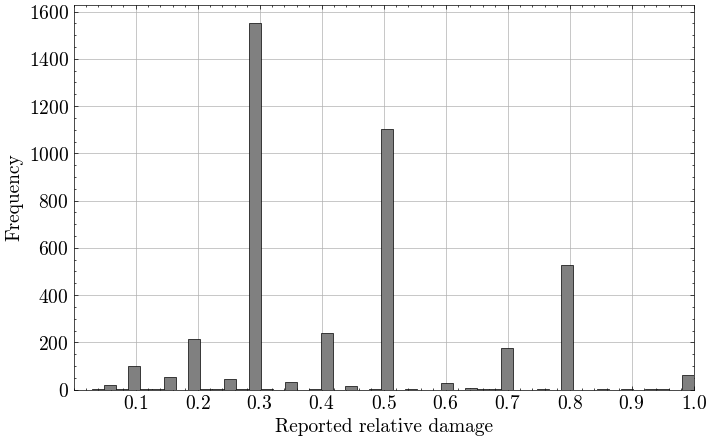

In [ ]:
plt.figure(figsize=(8, 5))
# sns.histplot(df["relative_damage"], bins=50)
# plt.title("Histogram of Relative Damage")
plt.hist(df["relative_damage"], edgecolor="darkgrey", color=colors.COLOR_OBSERVED, linewidth=0.5, bins=50)
plt.xlabel("Reported relative damage")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0,1)

plt.xticks(np.arange(0.1, 1.01, 0.1))

plt.savefig(IMAGES_PATH + "/05/validation_damage_histogram.pdf", dpi=300, bbox_inches="tight")
plt.show()


# 1. Calculate predicted relative using depth-damage function

In [21]:
# Calculate damage based on property type
df["predicted_relative_damage"] = df.apply(lambda row: get_damage_fraction(row["Objekt_VisinaVodeM"], row["property_type"]), axis=1)

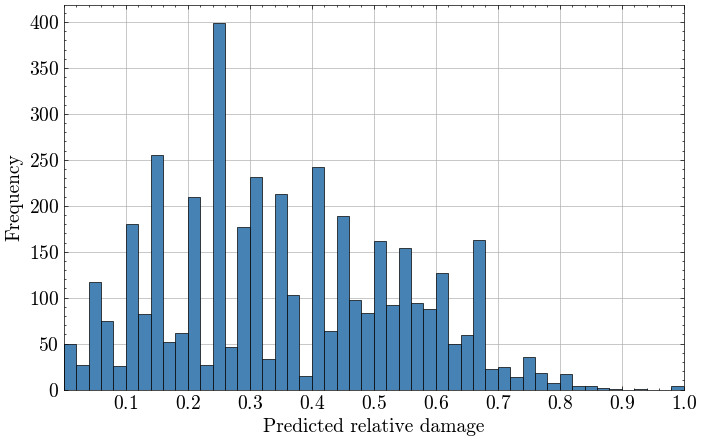

In [22]:
plt.figure(figsize=(8, 5))
# sns.histplot(df["relative_damage"], bins=50)
# plt.title("Histogram of Relative Damage")
plt.hist(df["predicted_relative_damage"], edgecolor="black", color="steelblue", linewidth=0.5, bins=50)
plt.xlabel("Predicted relative damage")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0,1)

plt.xticks(np.arange(0.1, 1.01, 0.1))

# plt.savefig(IMAGES_PATH + "/05/predicted_damage_histogram.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [23]:
df.head()

,VlogaId,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Objekt_StopnjaPoskodovanosti,Objekt_CentroidX,Objekt_CentroidY,Skoda_DatumOcene,Objekt_SkodaPovzrocenaVPlazu,Objekt_VrstaObjektaId,DogodekId,Vrednost,OdstPoskodovanostiObjekta,SkupnaSkoda,SkupnaSkodaSource,relative_damage,Objekt_VisinaVodeM,water_height_bucket,property_type,predicted_relative_damage
206,149162,Čužnja vas 12,8231 TREBELNO,2501/3,1449,35.00,0.0,NaN,515501.0,85416.0,10/15/10 00:00:00,NaN,2.0,14,3309.35,100.0,3309.35,Postavka3,1.0,0.0,NaN,residential,0.0
788,155809,Poklek nad Blanco 10,8283 BLANCA,172/0.S,2307,214.54,0.0,NaN,530288.0,97018.0,10/21/10 00:00:00,NaN,2.0,14,72396.27,100.0,72396.27,Postavka3,1.0,0.0,NaN,residential,0.0
1296,152700,Vrh nad Laškim 3,3270 LAŠKO,187/0.S,1705,161.65,40.0,NaN,521876.0,109619.0,09/28/10 00:00:00,NaN,2.0,14,54338.48,100.0,54338.48,Postavka3,1.0,0.4,0.0-0.5m,residential,0.2
1298,157182,Obrežje pri Zidanem Mostu 50,1432 ZIDANI MOST,576/2,1625,196.41,0.0,NaN,513876.0,104422.0,11/04/10 00:00:00,NaN,2.0,14,61876.97,70.0,43313.88,Postavka3,0.7,0.0,NaN,residential,0.0
1299,157304,Obrežje pri Zidanem Mostu 49,1432 ZIDANI MOST,22/8.S,1625,57.75,0.0,NaN,513884.0,104450.0,11/04/10 00:00:00,NaN,2.0,14,14169.51,100.0,14169.51,Postavka3,1.0,0.0,NaN,residential,0.0


In [24]:
# Show number of samples, split by event
event_sample_counts = df["DogodekId"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)

Number of samples split by event:
DogodekId
68    4171
18      15
14      13
24       1
Name: count, dtype: int64


In [25]:
# Show number of samples, split by property_type
_sample_counts = df["property_type"].value_counts()
print("Number of samples split by property_type:")
print(_sample_counts)

Number of samples split by property_type:
property_type
residential    3249
agriculture     586
commercial      218
industrial      147
Name: count, dtype: int64


In [26]:
# Show number of samples, split by property_type
_sample_counts = df["water_height_bucket"].value_counts()
print("Number of samples split by water_height_bucket:")
print(_sample_counts)

Number of samples split by water_height_bucket:
water_height_bucket
0.0-0.5m    1527
0.5-1.0m    1144
1.0-1.5m     659
1.5-2.0m     497
Name: count, dtype: int64


(0.0, 300.0)

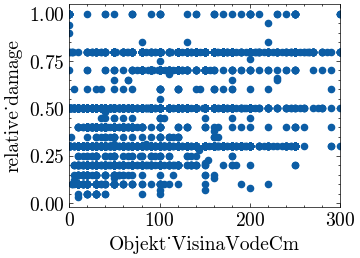

In [27]:

df.plot(x="Objekt_VisinaVodeCm", y="relative_damage", kind="scatter")
plt.xlim(0, 300)

In [28]:
def plot_violin_damage_by_water_height(df, title: str = "", ax=None, fontsize=20):
    _df = df.copy()
    total_samples = len(_df)
    
    # Create the figure and axis
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    else:
        fig = ax.get_figure()

    # Plot violins
    smsplot = sns.violinplot(
        data=_df,
        x="water_height_bucket",
        y="relative_damage",
        cut=0,  # limit the violin plot to actual data range
        ax=ax, # specify the axis to plot on
        color="steelblue",
    )
    smsplot.set_ylabel("Relative damage", fontsize=fontsize)
    smsplot.tick_params(axis="x", labelsize=fontsize)
    smsplot.tick_params(axis="y", labelsize=fontsize)

    # Adjust x-axis to show ticks at the upper bounds of each bucket
    ax.set_xticks(range(len(bucket_edges)-1))
    ax.set_xticklabels([f"{x}m" for x in bucket_edges[1:]])

    # Set y-axis range from 0 to 1
    ax.set_ylim(0, 1)

    # Add count and median annotations for each bucket
    # Calculate and plot median values
    medians = _df.groupby("water_height_bucket", observed=False)["relative_damage"].median()
    for i, median in enumerate(medians):
        # Add horizontal line for median
        ax.hlines(median, i-0.2, i+0.2, colors="black", linestyles="-.", alpha=1)
        print(f"Median for {bucket_edges[i+1]}m: {median}")

    # bucket_counts = _df["water_height_bucket"].value_counts().sort_index()
    # for i, (count, median) in enumerate(zip(bucket_counts, medians)):
    #     ax.text(
    #         i,
    #         ax.get_ylim()[0],
    #         f"n={count}\nmed={median:.2f}",
    #         ha="center", va="bottom",
    #         bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    # Customize the plot
    if title != "NO":
        ctitle = f"Distribution of Relative Damage by Water Height (Total Samples: {total_samples})"
        if title:
            ctitle += f" - {title}"
        ax.set_title(ctitle)
    ax.set_xlabel("Water depth [m]")
    ax.set_ylabel("Relative damage")
    ax.tick_params(axis="x", rotation=45)

    # Add grid for better readability
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)
    fig.tight_layout()

    # Hide x 
    
    return fig, ax

def plot_damage_function(
    damage_function,
    color="orange",
    label="NONE",
    show_title=True,
    ax=None,
    calibrated_damage_function: callable = None
):
    if ax is None:
        fig = plt.gcf()
        ax = plt.gca()
    else:
        fig = ax.get_figure()

    damage_function = [(h, d) for h, d in damage_function if h <= 2.5]
    flood_depths = [i[0] for i in damage_function]
    damage_fractions = [i[1] for i in damage_function]

    # if damage_function_dashed is not None:
    #     damage_function_dashed = [(h, d) for h, d in damage_function_dashed if h <= 2.5]
    #     flood_depths_dashed = [i[0] for i in damage_function_dashed]
    #     damage_fractions_dashed = [i[1] for i in damage_function_dashed]
    
    if calibrated_damage_function is not None:
        damage_fractions_calibrated = [calibrated_damage_function(h) for h in flood_depths]

    def get_damage_fraction(depth, _damage_fractions=damage_fractions):
        """
        Get damage fraction for a given flood depth using polynomial interpolation.
        For depths outside the range, we clamp the values to [0, 1].
        
        Args:
            depth (float): Flood depth in meters
            
        Returns:
            float: Damage fraction between 0 and 1
        """
        # Create interpolation function
        f = interp1d(flood_depths, _damage_fractions, kind="linear", bounds_error=False, fill_value=(0, 1))
        return float(f(depth))

    # Create points for smooth curve visualization
    depths_smooth = np.linspace(0, max(flood_depths), 100)
    damage_smooth = [get_damage_fraction(d, _damage_fractions=damage_fractions) for d in depths_smooth]

    # Plot the data and fitted curve
    ax.plot([(i - 0.5)*2 for i in flood_depths], damage_fractions, "o", color=color)
    # Dont show this in legend
    ax.plot([(i - 0.5)*2 for i in depths_smooth], damage_smooth, "-", label=label, color=color)

    if calibrated_damage_function is not None:
        damage_calibrated_smooth = [calibrated_damage_function(d) for d in depths_smooth]

        # Plot the data and fitted curve
        ax.plot([(i - 0.5)*2 for i in flood_depths], damage_fractions_calibrated, "o", color="red")
        # Dont show this in legend
        ax.plot([(i - 0.5)*2 for i in depths_smooth], damage_calibrated_smooth, "--", label=label + " - calibrated", color="red")

    ax.set_xlim(-1, 4)
    
    # Set y-axis range from 0 to 1
    # ax.set_ylim(0, 1)
    
    # Add labels and title
    # ax.set_xlabel("Water Height (m)")
    # ax.set_ylabel("Damage Fraction")
    # ax.set_title("Damage Function")
    # ax.grid(True, linestyle="--", alpha=0.7)
    
    # Return the figure and axis for further customization
    return fig, ax


Median for 0.5m: 0.3
Median for 1.0m: 0.4
Median for 1.5m: 0.5
Median for 2.0m: 0.5


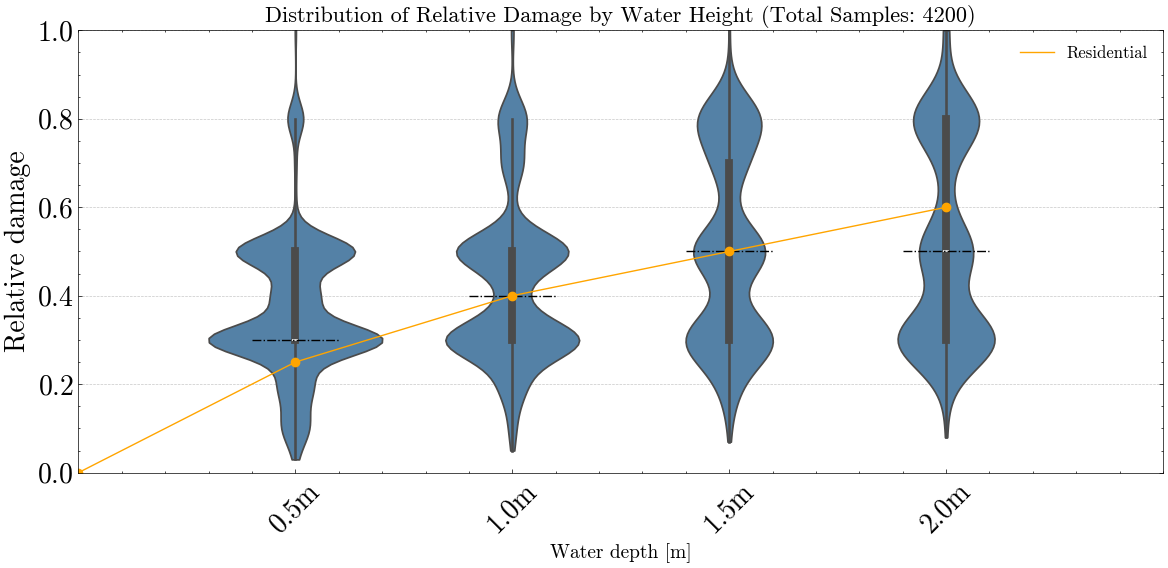

In [29]:
_df = df.copy()
# _df = _df[_df["Objekt_VrstaObjektaId"].isin([1, 2, 4, 5])]
fig, ax = plot_violin_damage_by_water_height(_df)
fig, ax = plot_damage_function(residential_damage_fractions, color="orange", label="Residential")
# fig, ax = plot_damage_function(commercial_damage_function, color="red", label="Commercial")
# fig, ax = plot_damage_function(industrial_damage_function, color="purple", label="Industrial")
# fig, ax = plot_damage_function(agriculture_damage_function, color="green", label="Agriculture")

ax.legend()

Original font size: 14.0
Median for 0.5m: 0.3
Median for 1.0m: 0.4
Median for 1.5m: 0.5
Median for 2.0m: 0.5
ploted for  residential
---------------
Median for 0.5m: 0.3
Median for 1.0m: 0.5
Median for 1.5m: 0.8
Median for 2.0m: 0.8
ploted for  industrial
---------------
Median for 0.5m: 0.3
Median for 1.0m: 0.42500000000000004
Median for 1.5m: 0.5
Median for 2.0m: 0.65
ploted for  commercial
---------------
Median for 0.5m: 0.3
Median for 1.0m: 0.3
Median for 1.5m: 0.5
Median for 2.0m: 0.5
ploted for  agriculture
---------------


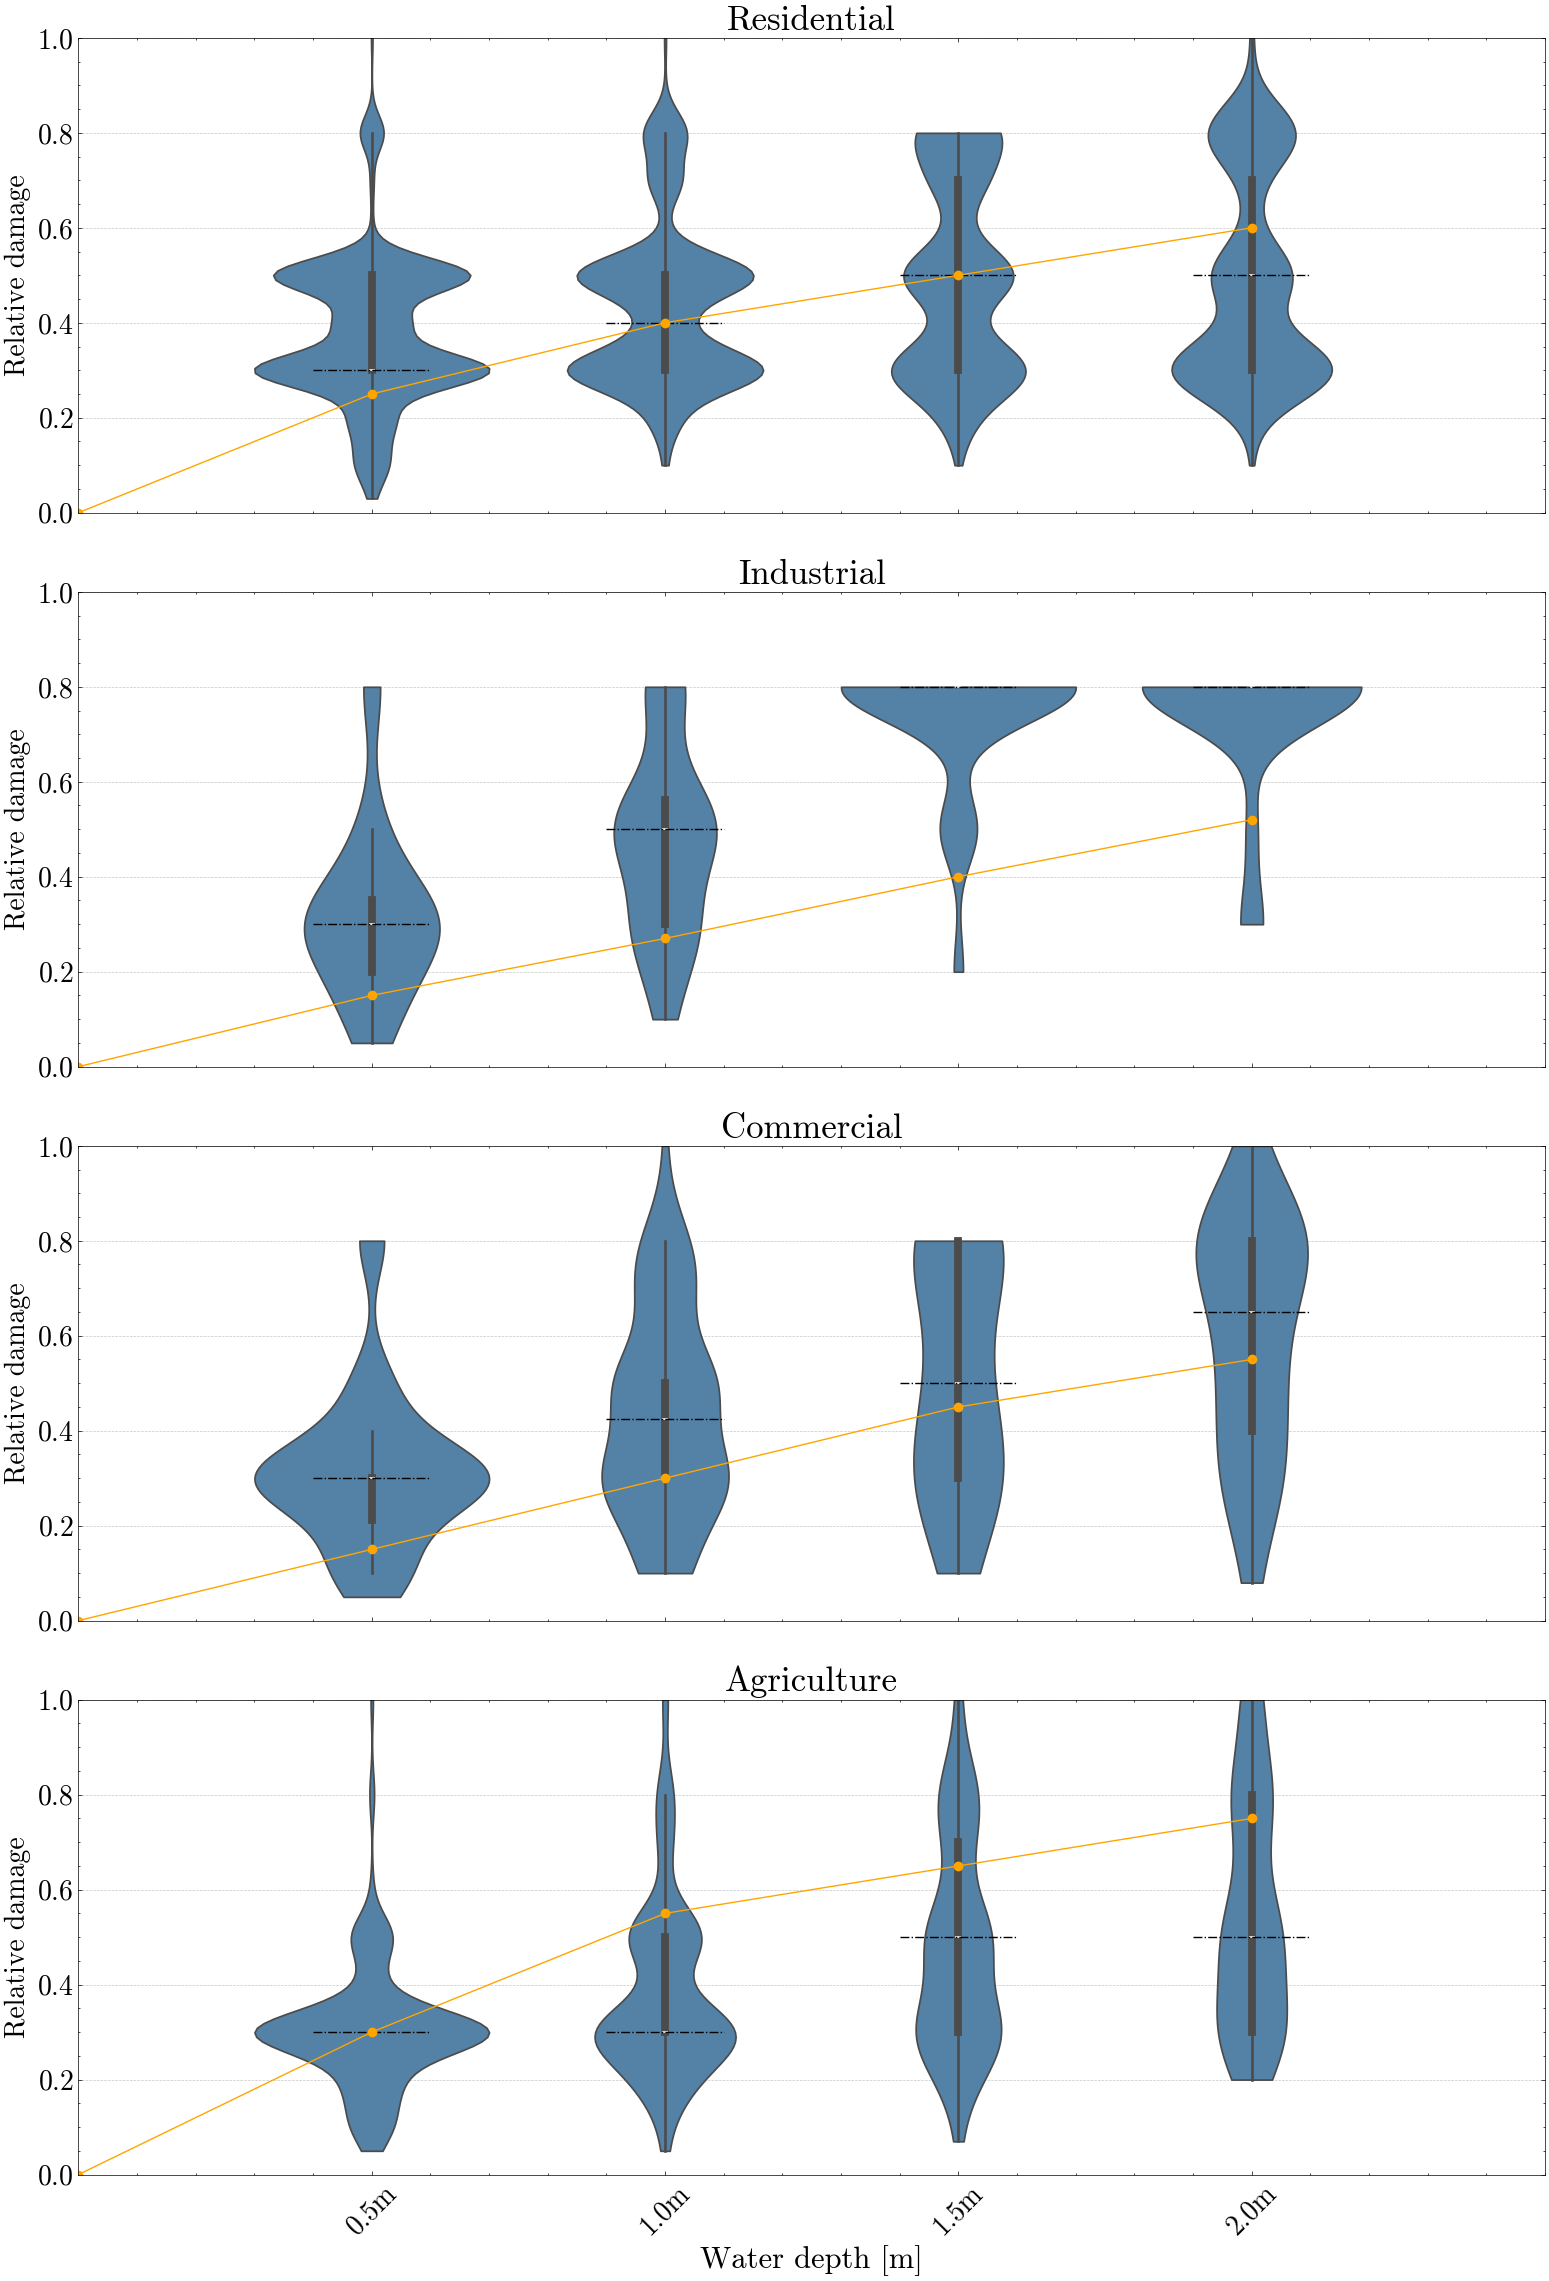

In [33]:
fontsize = 20
sizefactor = 0.8
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(20*sizefactor, 29*sizefactor))

# Increase text font size
original_font_size = plt.rcParams['font.size']
print(f"Original font size: {original_font_size}")

for no, (property_type, damage_function) in enumerate([
    ("residential", residential_damage_fractions,),
    ("industrial", industrial_damage_function,),
    ("commercial", commercial_damage_function,),
    ("agriculture", agriculture_damage_function,),
]):  
    plt.rcParams.update({'font.size': fontsize})
    _df = df.copy()
    _df = _df[_df["property_type"] == property_type]

    ax = axes[no]
    
    # _df = _df[_df["Objekt_VrstaObjektaId"].isin(vrste_objekta_id)]
    # plot_violin_damage_by_water_height(_df)
    fig, ax = plot_violin_damage_by_water_height(_df, title="NO", ax=ax)#title=property_type, title="NO")
    fig, ax = plot_damage_function(damage_function, color="orange", label=property_type.capitalize() + " DDF", ax=ax)
    
    # ax.legend()
    ax.set_title(property_type.capitalize(), fontsize=fontsize + 5)
    # Hide x-axis ticks
    if no != 3:
        ax.set_xlabel(None)
        ax.set_xticklabels([])
    print("ploted for ", property_type)
    print("---------------")

    # plt.savefig(IMAGES_PATH + f"/05/violin_damage_by_water_height_bucker_{property_type}.pdf", dpi=300, bbox_inches="tight")
    

axes[-1].set_xlabel("Water depth [m]", fontsize=fontsize+2, fontweight="bold")
# axes[-1].tick_params(axis="x", labelrotation=45)

# plt.savefig(IMAGES_PATH + f"/05/violin_damage_by_water_height_bucket_all.pdf", dpi=300, bbox_inches="tight")
# plt.savefig(IMAGES_PATH + f"/05/violin_damage_by_water_height_bucket_all_calibrated.pdf", dpi=300, bbox_inches="tight")

plt.rcParams.update({'font.size': original_font_size})

# Damage Function Performance Metrics

This section calculates advanced metrics to assess the performance of damage functions compared to observed data.



In [34]:
from scipy.stats import spearmanr

def calculate_error_metrics_by_depth_bucket(df, predicted_column:str = "predicted_relative_damage"):
    """
    Calculate error metrics by depth bucket.
    
    Calculates ME (Mean Error) and RMSE for observations within specific 
    depth intervals. Allows assessment of damage function performance across 
    different flood severity levels.
    
    Args:
        df: DataFrame with flood depth and damage observations
        predicted_column: Column name containing predicted damage values
        
    Returns:
        dict: Dictionary with bucket ranges as keys and statistics dict as values
    """
    # Create depth buckets
    df_copy = df.copy()
    
    # Create bucket labels
    bucket_labels = []
    for i in range(len(bucket_edges) - 1):
        bucket_labels.append(f"{bucket_edges[i]:.1f}-{bucket_edges[i+1]:.1f}m")
    
    # Remove observations with NaN bucket (beyond max_depth)
    df_copy = df_copy.dropna(subset=["water_height_bucket"])
    
    bucket_stats = {}
    
    for bucket in bucket_labels:
        bucket_data = df_copy[df_copy["water_height_bucket"] == bucket]
        
        if len(bucket_data) == 0:
            continue
            
        # Get predicted damage using the damage function
        predicted_damage = bucket_data[predicted_column]
        observed_damage = bucket_data["relative_damage"]
        
        # Calculate Mean Error (ME) - shows direction of bias
        # ME = mean(predicted - observed)
        # Positive ME = overprediction, Negative ME = underprediction
        errors = [pred - obs for pred, obs in zip(predicted_damage, observed_damage)]
        me = np.mean(errors)
        
        # Store statistics
        bucket_stats[bucket] = {
            "count": len(bucket_data),
            "mean_observed": np.mean(observed_damage),
            "mean_predicted": np.mean(predicted_damage),
            "me": me,  # Mean Error
            "rmse": np.sqrt(np.mean([(pred - obs)**2 for pred, obs in zip(predicted_damage, observed_damage)])),
            "std_error": np.std(errors),  # Standard deviation of errors
        }
    
    return bucket_stats

def calculate_spearman_correlation(df):
    """
    Calculate Spearman Correlation (ρs) between predicted and observed damage rankings.
    
    ρs measures the monotonic relationship between predicted and observed damage rankings. 
    Values close to 1 indicate strong positive correlation, suggesting the damage function 
    captures the relative ordering of impacts well.
    
    Args:
        df: DataFrame with flood depth and damage observations
        depth_col: Column name for flood depth in meters  
        damage_col: Column name for observed relative damage (0-1 scale)
        
    Returns:
        tuple: (correlation_coefficient, p_value)
    """
    # Remove any rows with missing data
    df_clean = df[["predicted_relative_damage", "relative_damage"]].dropna()
    
    # Get predicted damage using the damage function
    predicted_damage = df_clean["predicted_relative_damage"]
    observed_damage = df_clean["relative_damage"]
    
    # Calculate Spearman correlation
    correlation, p_value = spearmanr(predicted_damage, observed_damage)
    
    return correlation, p_value

def plot_error_metrics_by_depth_bucket(bucket_stats):
    """Plot ME and RMSE by depth bucket."""
    buckets = list(bucket_stats.keys())
    me_values = [bucket_stats[bucket]["me"] for bucket in buckets]
    rmse_values = [bucket_stats[bucket]["rmse"] for bucket in buckets]
    counts = [bucket_stats[bucket]["count"] for bucket in buckets]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot ME values with color coding
    colors = ['red' if me > 0 else 'blue' for me in me_values]
    bars1 = ax1.bar(buckets, me_values, color=colors, alpha=0.7, edgecolor='black')
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax1.set_ylabel("Mean Error (ME)")
    ax1.set_title("Mean Error by Depth Bucket")
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add count and ME labels on bars
    for bar, count, me in zip(bars1, counts, me_values):
        height = bar.get_height()
        label_y = height + (0.01 if height > 0 else -0.01)
        va = 'bottom' if height > 0 else 'top'
        ax1.text(bar.get_x() + bar.get_width()/2., label_y,
                f"n={count}\n{me:+.3f}", ha="center", va=va, fontsize=9)
    
    # Plot RMSE values
    bars2 = ax2.bar(buckets, rmse_values, color="orange", alpha=0.7, edgecolor='black')
    ax2.set_ylabel("RMSE")
    ax2.set_xlabel("Depth Bucket")
    ax2.set_title("RMSE by Depth Bucket")
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add RMSE labels on bars
    for bar, rmse in zip(bars2, rmse_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                f"{rmse:.3f}", ha="center", va="bottom", fontsize=9)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig

def plot_predicted_vs_observed_scatter(df, predicted_column:str = "predicted_relative_damage"):
    """Create scatter plot of predicted vs observed damage with Spearman correlation."""
    # Remove any rows with missing data
    df_clean = df[[predicted_column, "relative_damage"]].dropna()
    
    # Get predicted damage using the damage function
    predicted_damage = df_clean[predicted_column]
    observed_damage = df_clean["relative_damage"]
    
    # Calculate Spearman correlation
    correlation, p_value = spearmanr(predicted_damage, observed_damage)
    
    # Create scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create density plot for better visualization of overlapping points
    scatter = ax.scatter(observed_damage, predicted_damage, alpha=0.6, s=30)
    
    # Add perfect prediction line (y=x)
    max_val = max(max(predicted_damage), max(observed_damage))
    ax.plot([0, max_val], [0, max_val], "r--", alpha=0.8, linewidth=2, 
            label="Perfect prediction (y=x)")
    
    ax.set_xlabel("Observed Relative Damage")
    ax.set_ylabel("Predicted Relative Damage")
    ax.set_title(f"Predicted vs Observed Damage\\nSpearman ρ = {correlation:.3f} (p = {p_value:.3e})")
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Set equal aspect ratio and limits
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_aspect("equal")
    
    plt.tight_layout()
    return fig, correlation, p_value


## 1. Mean Error (ME) and RMSE by Depth Bucket

Calculate and visualize ME and RMSE metrics across different flood depth intervals.


In [35]:
# Calculate error metrics for the entire dataset
bucket_stats = calculate_error_metrics_by_depth_bucket(df)

# Display results
print("Error Metrics by Depth Bucket:")
print("=" * 90)
print(f"{'Bucket':>12} {'ME':>8} {'Bias':>12} | {'n':>5} {'Obs':>6} {'Pred':>6} {'RMSE':>6}")
print("-" * 90)
for bucket in bucket_stats:
    stats = bucket_stats[bucket]
    bias_direction = "OVERpred" if stats['me'] > 0 else "UNDERpred"
    print(f"{bucket:>12}: {stats['me']:+.3f} {bias_direction:>12} | "
          f"{stats['count']:>5} {stats['mean_observed']:>6.3f} {stats['mean_predicted']:>6.3f} {stats['rmse']:>6.3f}")

# Calculate overall statistics
overall_rmse = np.mean([stats['rmse'] for stats in bucket_stats.values()])
print(f"\nOverall RMSE (average across buckets): {overall_rmse:.3f}")

overall_me = np.mean([stats['me'] for stats in bucket_stats.values()])
bias_direction = "overpredicting" if overall_me > 0 else "underpredicting"
print(f"Overall ME (average across buckets): {overall_me:+.3f} ({bias_direction})")

total_observations = sum(stats['count'] for stats in bucket_stats.values())
print(f"\nTotal observations used: {total_observations}")
print(f"Total dataset size: {len(df)}")
print(f"Coverage: {total_observations/len(df)*100:.1f}%")

# Bias interpretation
print("\n" + "=" * 90)
print("BIAS ANALYSIS:")
print("=" * 90)
for bucket in bucket_stats:
    me = bucket_stats[bucket]['me']
    if me < -0.05:
        print(f"{bucket:>12}: Strong UNDERPREDICTION (ME = {me:+.3f})")
    elif me > 0.05:
        print(f"{bucket:>12}: Strong OVERPREDICTION (ME = {me:+.3f})")
    else:
        print(f"{bucket:>12}: Minimal bias (ME = {me:+.3f})")


Error Metrics by Depth Bucket:
      Bucket       ME         Bias |     n    Obs   Pred   RMSE
------------------------------------------------------------------------------------------
    0.0-0.5m: -0.199    UNDERpred |  1527  0.365  0.165  0.257
    0.5-1.0m: -0.077    UNDERpred |  1144  0.428  0.351  0.208
    1.0-1.5m: -0.025    UNDERpred |   659  0.503  0.478  0.231
    1.5-2.0m: +0.062     OVERpred |   497  0.513  0.575  0.245

Overall RMSE (average across buckets): 0.235
Overall ME (average across buckets): -0.060 (underpredicting)

Total observations used: 3827
Total dataset size: 4200
Coverage: 91.1%

BIAS ANALYSIS:
    0.0-0.5m: Strong UNDERPREDICTION (ME = -0.199)
    0.5-1.0m: Strong UNDERPREDICTION (ME = -0.077)
    1.0-1.5m: Minimal bias (ME = -0.025)
    1.5-2.0m: Strong OVERPREDICTION (ME = +0.062)


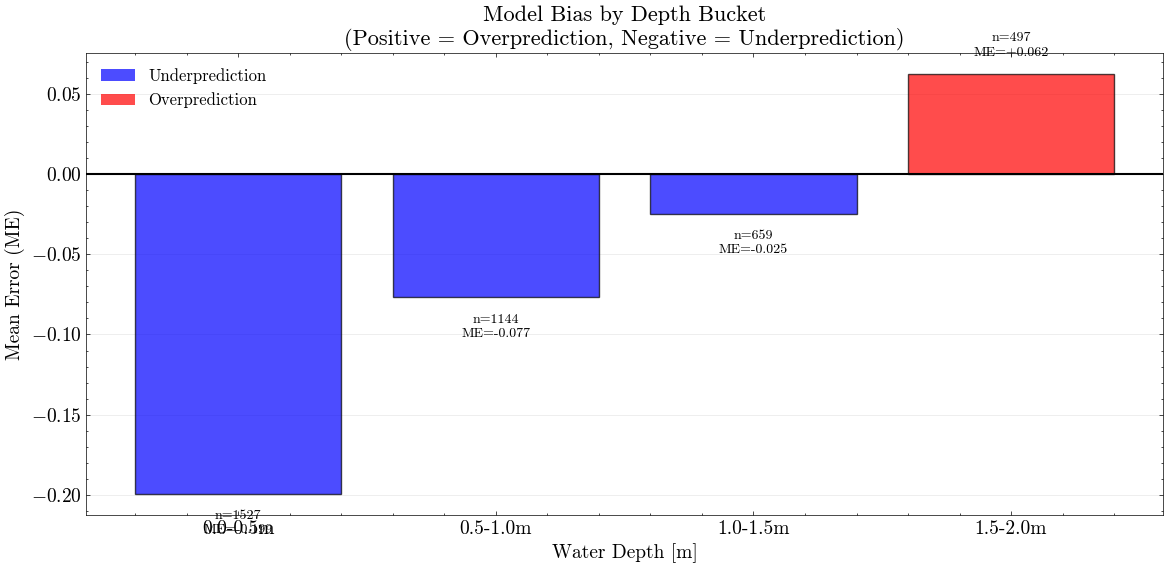


✓ Blue bars = Model underpredicts (pred < observed)
✓ Red bars = Model overpredicts (pred > observed)


In [36]:
# Visualize bias by depth bucket
buckets = list(bucket_stats.keys())
me_values = [bucket_stats[bucket]['me'] for bucket in buckets]
counts = [bucket_stats[bucket]['count'] for bucket in buckets]

fig, ax = plt.subplots(figsize=(12, 6))

# Create bar plot with colors based on bias direction
colors = ['red' if me > 0 else 'blue' for me in me_values]
bars = ax.bar(buckets, me_values, color=colors, alpha=0.7, edgecolor='black')

# Add horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

# Add sample count labels on bars
for bar, count, me in zip(bars, counts, me_values):
    height = bar.get_height()
    label_y = height + (0.01 if height > 0 else -0.01)
    va = 'bottom' if height > 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2., label_y,
            f'n={count}\nME={me:+.3f}', 
            ha='center', va=va, fontsize=10, fontweight='bold')

ax.set_ylabel('Mean Error (ME)', fontsize=14, fontweight='bold')
ax.set_xlabel('Water Depth [m]', fontsize=14, fontweight='bold')
ax.set_title('Model Bias by Depth Bucket\n(Positive = Overprediction, Negative = Underprediction)', 
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.7, label='Underprediction'),
    Patch(facecolor='red', alpha=0.7, label='Overprediction')
]
ax.legend(handles=legend_elements, loc='best', fontsize=12)

plt.tight_layout()
plt.savefig(IMAGES_PATH + "/05/bias_by_depth_bucket.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Blue bars = Model underpredicts (pred < observed)")
print("✓ Red bars = Model overpredicts (pred > observed)")


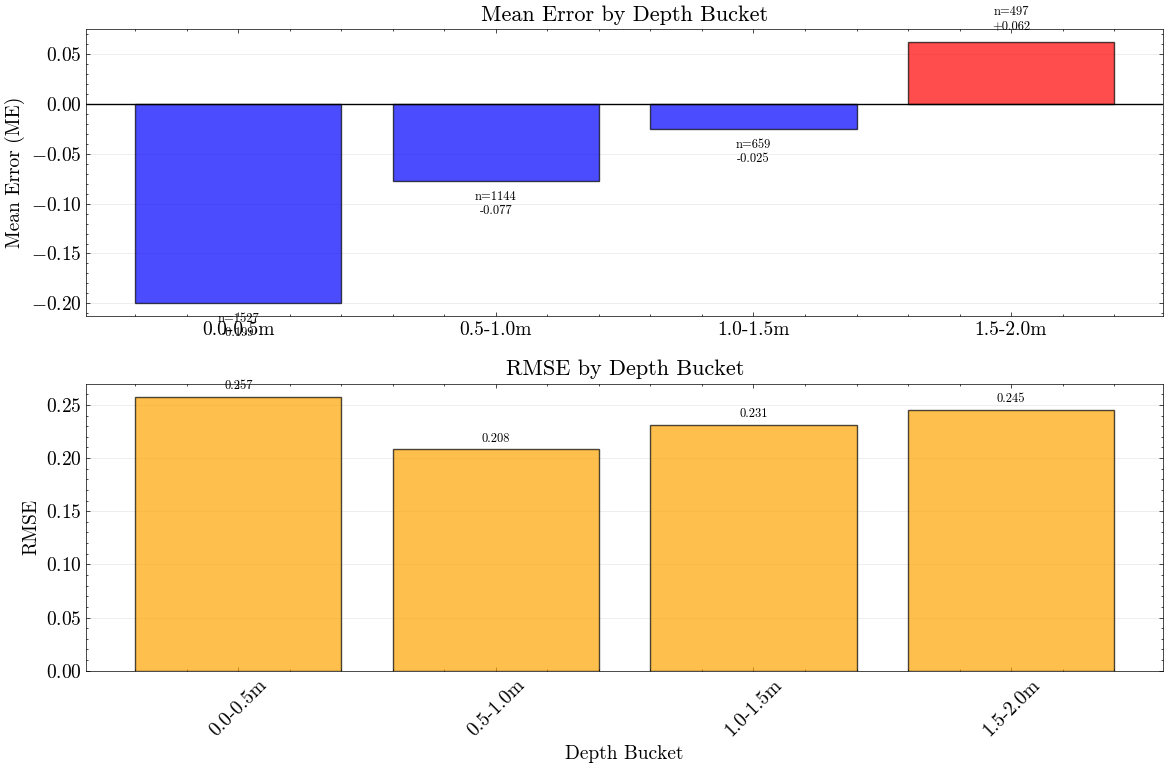

In [37]:
# Plot error metrics visualization
fig = plot_error_metrics_by_depth_bucket(bucket_stats)
# plt.savefig(IMAGES_PATH + "/05/error_metrics_by_depth_bucket.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 2. Spearman Correlation (ρs)

Calculate and visualize the Spearman correlation between predicted and observed damage rankings.


In [38]:
# Calculate Spearman correlation for the entire dataset
correlation, p_value = calculate_spearman_correlation(
    df
)

print("Spearman Correlation Analysis:")
print("=" * 40)
print(f"Spearman correlation coefficient (ρs): {correlation:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Sample size: {len(df[['Objekt_VisinaVodeM', 'relative_damage']].dropna())}")

# Interpret the correlation strength
if abs(correlation) >= 0.7:
    strength = "strong"
elif abs(correlation) >= 0.5:
    strength = "moderate"
elif abs(correlation) >= 0.3:
    strength = "weak"
else:
    strength = "very weak"

direction = "positive" if correlation > 0 else "negative"
significance = "significant" if p_value < 0.05 else "not significant"

print(f"\nInterpretation:")
print(f"- Correlation strength: {strength} {direction} correlation")
print(f"- Statistical significance: {significance} (α = 0.05)")

if correlation > 0.5:
    print("- The damage function captures the relative ordering of impacts reasonably well")
else:
    print("- The damage function may not adequately capture the relative ordering of impacts")


Spearman Correlation Analysis:
Spearman correlation coefficient (ρs): 0.2431
P-value: 1.44e-57
Sample size: 4200

Interpretation:
- Correlation strength: very weak positive correlation
- Statistical significance: significant (α = 0.05)
- The damage function may not adequately capture the relative ordering of impacts


/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_21140/2932965943.py:163: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) cmr10.
  plt.tight_layout()
/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_21140/1038170978.py:5: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) cmr10.
  plt.savefig(IMAGES_PATH + "/05/predicted_vs_observed_damage_scatter.pdf", dpi=300, bbox_inches="tight")
/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_21140/1038170978.py:5: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) cmr10.
  plt.savefig(IMAGES_PATH + "/05/predicted_vs_observed_damage_scatter.pdf", dpi=300, bbox_inches="tight")
/Users/klemenkubelj/miniconda3/envs/cvar-masters/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


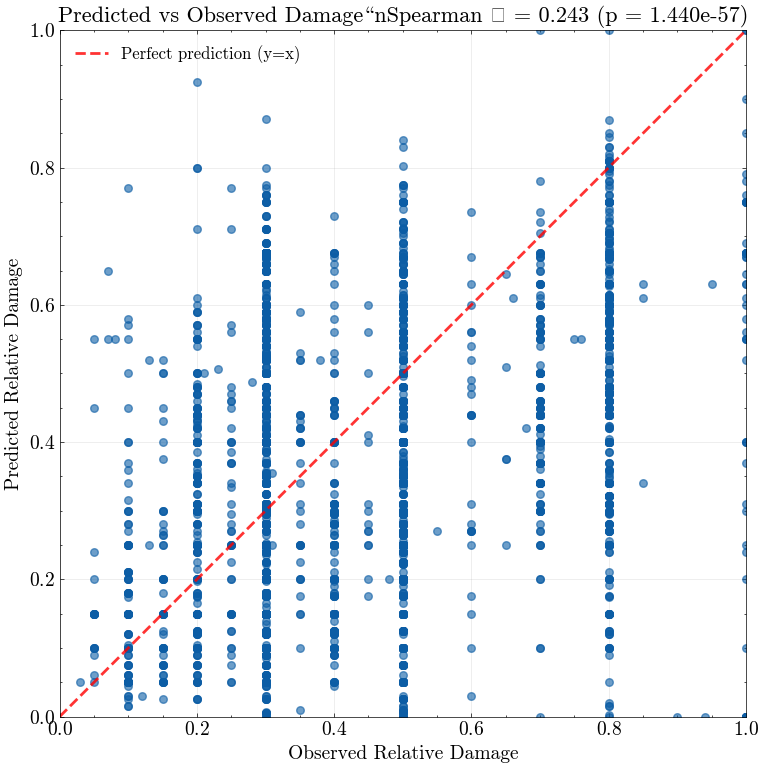

In [39]:
# # Create scatter plot of predicted vs observed damage
fig, corr, p_val = plot_predicted_vs_observed_scatter(
    df
)
plt.savefig(IMAGES_PATH + "/05/predicted_vs_observed_damage_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 3. Analysis by Building Type

Calculate metrics separately for different building types to understand performance variations.


In [40]:
# Define building type mappings
property_types = [
    "residential",
    "industrial",
    "commercial",
    "agriculture",
]

print("Analysis by Building Type:")
print("=" * 50)

# Store results for comparison
building_type_results = {}

for property_type in property_types:
    # Filter data for this building type
    type_df = df[df["property_type"] == property_type]
    
    if len(type_df) < 10:  # Skip if too few samples
        print(f"\n{property_type}: Insufficient data (n={len(type_df)})")
        continue
    
    print(f"\n{property_type}:")
    print(f"Sample size: {len(type_df)}")
    
    # Calculate error metrics for this building type
    bucket_stats_type = calculate_error_metrics_by_depth_bucket(
        type_df,
    )
    
    # Calculate Spearman correlation
    correlation_type, p_value_type = calculate_spearman_correlation(
        type_df,
    )
    
    # Calculate overall metrics
    if bucket_stats_type:
        all_rmses = [bucket_stats_type[bucket]['rmse'] for bucket in bucket_stats_type]
        overall_rmse_type = np.mean(all_rmses)
        all_mes = [bucket_stats_type[bucket]['me'] for bucket in bucket_stats_type]
        overall_me_type = np.mean(all_mes)
        bias_direction = "overpredicting" if overall_me_type > 0 else "underpredicting"
        print(f"Overall RMSE: {overall_rmse_type:.3f}")
        print(f"Overall ME: {overall_me_type:+.3f} ({bias_direction})")
    else:
        overall_rmse_type = overall_me_type = None
        print("No data in depth buckets")
    
    print(f"Spearman ρs: {correlation_type:.4f} (p = {p_value_type:.2e})")
    
    # Store results
    building_type_results[property_type] = {
        "sample_size": len(type_df),
        "overall_rmse": overall_rmse_type,
        "overall_me": overall_me_type,
        "spearman_correlation": correlation_type,
        "spearman_p_value": p_value_type,
        "bucket_stats": bucket_stats_type,
    }


Analysis by Building Type:

residential:
Sample size: 3249
Overall RMSE: 0.225
Overall ME: -0.067 (underpredicting)
Spearman ρs: 0.2266 (p = 4.07e-39)

industrial:
Sample size: 147
Overall RMSE: 0.327
Overall ME: -0.280 (underpredicting)
Spearman ρs: 0.6063 (p = 4.02e-16)

commercial:
Sample size: 218
Overall RMSE: 0.263
Overall ME: -0.143 (underpredicting)
Spearman ρs: 0.4815 (p = 4.70e-14)

agriculture:
Sample size: 586
Overall RMSE: 0.229
Overall ME: +0.072 (overpredicting)
Spearman ρs: 0.3487 (p = 3.42e-18)


In [41]:
# Create summary table of results
print("\n\nSummary Table:")
print("=" * 95)
print(f"{'Building Type':<20} {'Sample':<8} {'ME':<10} {'Bias':<15} {'RMSE':<8} {'Spearman ρs':<12} {'P-value':<10}")
print("-" * 95)

for type_name, results in building_type_results.items():
    rmse_str = f"{results['overall_rmse']:.3f}" if results['overall_rmse'] is not None else "N/A"
    me_str = f"{results['overall_me']:+.3f}" if results['overall_me'] is not None else "N/A"
    bias_dir = "overpred" if results['overall_me'] and results['overall_me'] > 0 else "underpred"
    print(
        f"{type_name:<20} {results['sample_size']:<8} {me_str:<10} {bias_dir:<15} {rmse_str:<8} "
        f"{results['spearman_correlation']:<12.4f} {results['spearman_p_value']:<10.2e}"
    )

# Overall results
print("-" * 95)
bias_overall_dir = "overpred" if overall_me > 0 else "underpred"
print(
    f"{'Overall (All Types)':<20} {len(df):<8} {overall_me:<10.3f} {bias_overall_dir:<15} {overall_rmse:<8.3f} "
    f"{correlation:<12.4f} {p_value:<10.2e}"
)




Summary Table:
Building Type        Sample   ME         Bias            RMSE     Spearman ρs  P-value   
-----------------------------------------------------------------------------------------------
residential          3249     -0.067     underpred       0.225    0.2266       4.07e-39  
industrial           147      -0.280     underpred       0.327    0.6063       4.02e-16  
commercial           218      -0.143     underpred       0.263    0.4815       4.70e-14  
agriculture          586      +0.072     overpred        0.229    0.3487       3.42e-18  
-----------------------------------------------------------------------------------------------
Overall (All Types)  4200     -0.060     underpred       0.235    0.2431       1.44e-57  


## 4. Summary and Interpretation

The calculated metrics provide insights into the performance of the JRC depth-damage function when applied to Slovenian flood damage data:


In [42]:
print("Key Findings:")
print("=" * 50)

print(f"\n1. Mean Error (ME): {overall_me:.3f}")
print("   - This measures the average bias (systematic over/underprediction)")
print("   - Negative values = underprediction, Positive values = overprediction")
print("   - Values close to 0 indicate minimal systematic bias")

print(f"\n2. Root Mean Squared Error (RMSE): {overall_rmse:.3f}")
print("   - This measures the overall magnitude of prediction errors")
print("   - Lower values indicate better prediction accuracy")
print("   - Penalizes large errors more than small errors")

print(f"\n3. Spearman Correlation (ρs): {correlation:.4f}")
print("   - This measures how well the damage function captures relative damage rankings")
print("   - Values close to 1.0 indicate strong monotonic relationship")
print("   - Values close to 0 indicate poor ranking performance")

if correlation > 0.7:
    ranking_performance = "excellent"
elif correlation > 0.5:
    ranking_performance = "good"
elif correlation > 0.3:
    ranking_performance = "moderate"
else:
    ranking_performance = "poor"

print(f"\n4. Overall Assessment:")
print(f"   - Ranking performance: {ranking_performance}")
print(f"   - Statistical significance: {'Yes' if p_value < 0.05 else 'No'} (p = {p_value:.2e})")

# Identify best and worst performing building types
if building_type_results:
    valid_results = {k: v for k, v in building_type_results.items() 
                    if v['overall_me'] is not None}
    
    if valid_results:
        # Best ME = closest to 0 (least bias)
        best_me_type = min(valid_results.keys(), key=lambda x: abs(valid_results[x]['overall_me']))
        # Worst ME = furthest from 0 (most bias)
        worst_me_type = max(valid_results.keys(), key=lambda x: abs(valid_results[x]['overall_me']))
        
        best_rmse_type = min(valid_results.keys(), key=lambda x: valid_results[x]['overall_rmse'])
        worst_rmse_type = max(valid_results.keys(), key=lambda x: valid_results[x]['overall_rmse'])
        
        best_corr_type = max(valid_results.keys(), key=lambda x: valid_results[x]['spearman_correlation'])
        worst_corr_type = min(valid_results.keys(), key=lambda x: valid_results[x]['spearman_correlation'])
        
        print(f"\n5. Building Type Performance:")
        print(f"   - Least biased (best ME): {best_me_type} (ME = {valid_results[best_me_type]['overall_me']:+.3f})")
        print(f"   - Most biased (worst ME): {worst_me_type} (ME = {valid_results[worst_me_type]['overall_me']:+.3f})")
        print(f"   - Best RMSE: {best_rmse_type} ({valid_results[best_rmse_type]['overall_rmse']:.3f})")
        print(f"   - Worst RMSE: {worst_rmse_type} ({valid_results[worst_rmse_type]['overall_rmse']:.3f})")
        print(f"   - Best correlation: {best_corr_type} ({valid_results[best_corr_type]['spearman_correlation']:.3f})")
        print(f"   - Worst correlation: {worst_corr_type} ({valid_results[worst_corr_type]['spearman_correlation']:.3f})")

print(f"\n5. Data Coverage:")
print(f"   - Total observations: {len(df):,}")
print(f"   - Observations with flood depth ≤ 3m: {total_observations:,} ({total_observations/len(df)*100:.1f}%)")
print(f"   - This analysis focuses on the most common flood depth range")


Key Findings:

1. Mean Error (ME): -0.060
   - This measures the average bias (systematic over/underprediction)
   - Negative values = underprediction, Positive values = overprediction
   - Values close to 0 indicate minimal systematic bias

2. Root Mean Squared Error (RMSE): 0.235
   - This measures the overall magnitude of prediction errors
   - Lower values indicate better prediction accuracy
   - Penalizes large errors more than small errors

3. Spearman Correlation (ρs): 0.2431
   - This measures how well the damage function captures relative damage rankings
   - Values close to 1.0 indicate strong monotonic relationship
   - Values close to 0 indicate poor ranking performance

4. Overall Assessment:
   - Ranking performance: poor
   - Statistical significance: Yes (p = 1.44e-57)

5. Building Type Performance:
   - Least biased (best ME): residential (ME = -0.067)
   - Most biased (worst ME): industrial (ME = -0.280)
   - Best RMSE: residential (0.225)
   - Worst RMSE: industrial 

In [43]:
def plot_four_property_types_onecol(
    df,
    bucket_edges,
    figsize=(12, 16),
    add_ddf=True,
    suptitle=None,
    save_path=None,
):
    """
    Plot four subplots (1 column x 4 rows), one per property_type, sharing the x-axis.
    Each subplot shows the violin distribution of observed relative damage by water-depth bucket
    and optionally overlays the corresponding depth-damage function sampled at bucket centers.

    Args:
        df (pd.DataFrame): Input dataframe with columns "property_type", "water_height_bucket", and "relative_damage".
        bucket_edges (array-like): Numeric bin edges used to create the buckets.
        figsize (tuple): Figure size.
        add_ddf (bool): If True, overlay the damage function curve sampled at bucket centers.
        suptitle (str|None): Optional figure title.
        save_path (str|None): If provided, save the figure to this path.

    Returns:
        (fig, axes): Matplotlib figure and axes array of length 4.
    """
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.interpolate import interp1d

    property_types = [
        "residential",
        "industrial",
        "commercial",
        "agriculture",
    ]

    # Map property types to damage functions and colors
    ddf_map = {
        "residential": residential_damage_fractions,
        "industrial": industrial_damage_function,
        "commercial": commercial_damage_function,
        "agriculture": agriculture_damage_function,
    }
    color_map = {
        "residential": "orange",
        "industrial": "purple",
        "commercial": "red",
        "agriculture": "green",
    }

    # Prepare x mapping: categories are positioned at 0..n-1; we label with bucket upper bounds
    num_bins = len(bucket_edges) - 1
    x_positions = np.arange(num_bins)
    bucket_labels = [f"{x}m" for x in bucket_edges[1:]]
    centers_m = 0.5 * (np.array(bucket_edges[:-1]) + np.array(bucket_edges[1:]))

    fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=figsize)

    for idx, ptype in enumerate(property_types):
        ax = axes[idx]
        sub_df = df[df["property_type"] == ptype].copy()

        # Violin plot on this axis
        sns.violinplot(
            data=sub_df,
            x="water_height_bucket",
            y="relative_damage",
            cut=0,
            ax=ax,
        )

        # Force x positions to 0..n-1 with desired numeric tick labels
        ax.set_xticks(x_positions)
        ax.set_xticklabels(bucket_labels)

        # Y limits and grid
        ax.set_ylim(0, 1)
        ax.grid(True, axis="y", linestyle="--", alpha=0.7)

        # Median markers per bucket
        medians = sub_df.groupby("water_height_bucket", observed=False)["relative_damage"].median()
        for i, median in enumerate(medians):
            ax.hlines(median, i - 0.2, i + 0.2, colors="black", linestyles="-.", alpha=1)

        # Overlay DDF sampled at bucket centers
        if add_ddf and ptype in ddf_map:
            ddf = [(h, d) for h, d in ddf_map[ptype] if h <= bucket_edges[-1]]
            if len(ddf) >= 2:
                depths = np.array([h for h, _ in ddf])
                losses = np.array([d for _, d in ddf])
                f = interp1d(depths, losses, kind="linear", bounds_error=False, fill_value=(0, 1))
                y_vals = np.clip(f(centers_m), 0, 1)
                ax.plot(x_positions, y_vals, "-o", color=color_map[ptype], label=f"{ptype.capitalize()} DDF")
                ax.legend()

        # Titles and y-labels
        ax.set_title(f"{ptype.capitalize()} (n={len(sub_df)})")
        ax.set_ylabel("Relative damage")

        # Hide x tick labels for all but the bottom axis
        if idx < len(property_types) - 1:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

    # Bottom axis x label
    axes[-1].set_xlabel("Water depth [m]")
    axes[-1].tick_params(axis="x", labelrotation=45)

    if suptitle:
        fig.suptitle(suptitle)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes


(<Figure size 1200x1600 with 4 Axes>,
 array([<Axes: title={'center': 'Residential (n=3249)'}, ylabel='Relative damage'>,
        <Axes: title={'center': 'Industrial (n=147)'}, ylabel='Relative damage'>,
        <Axes: title={'center': 'Commercial (n=218)'}, ylabel='Relative damage'>,
        <Axes: title={'center': 'Agriculture (n=586)'}, xlabel='Water depth [m]', ylabel='Relative damage'>],
       dtype=object))

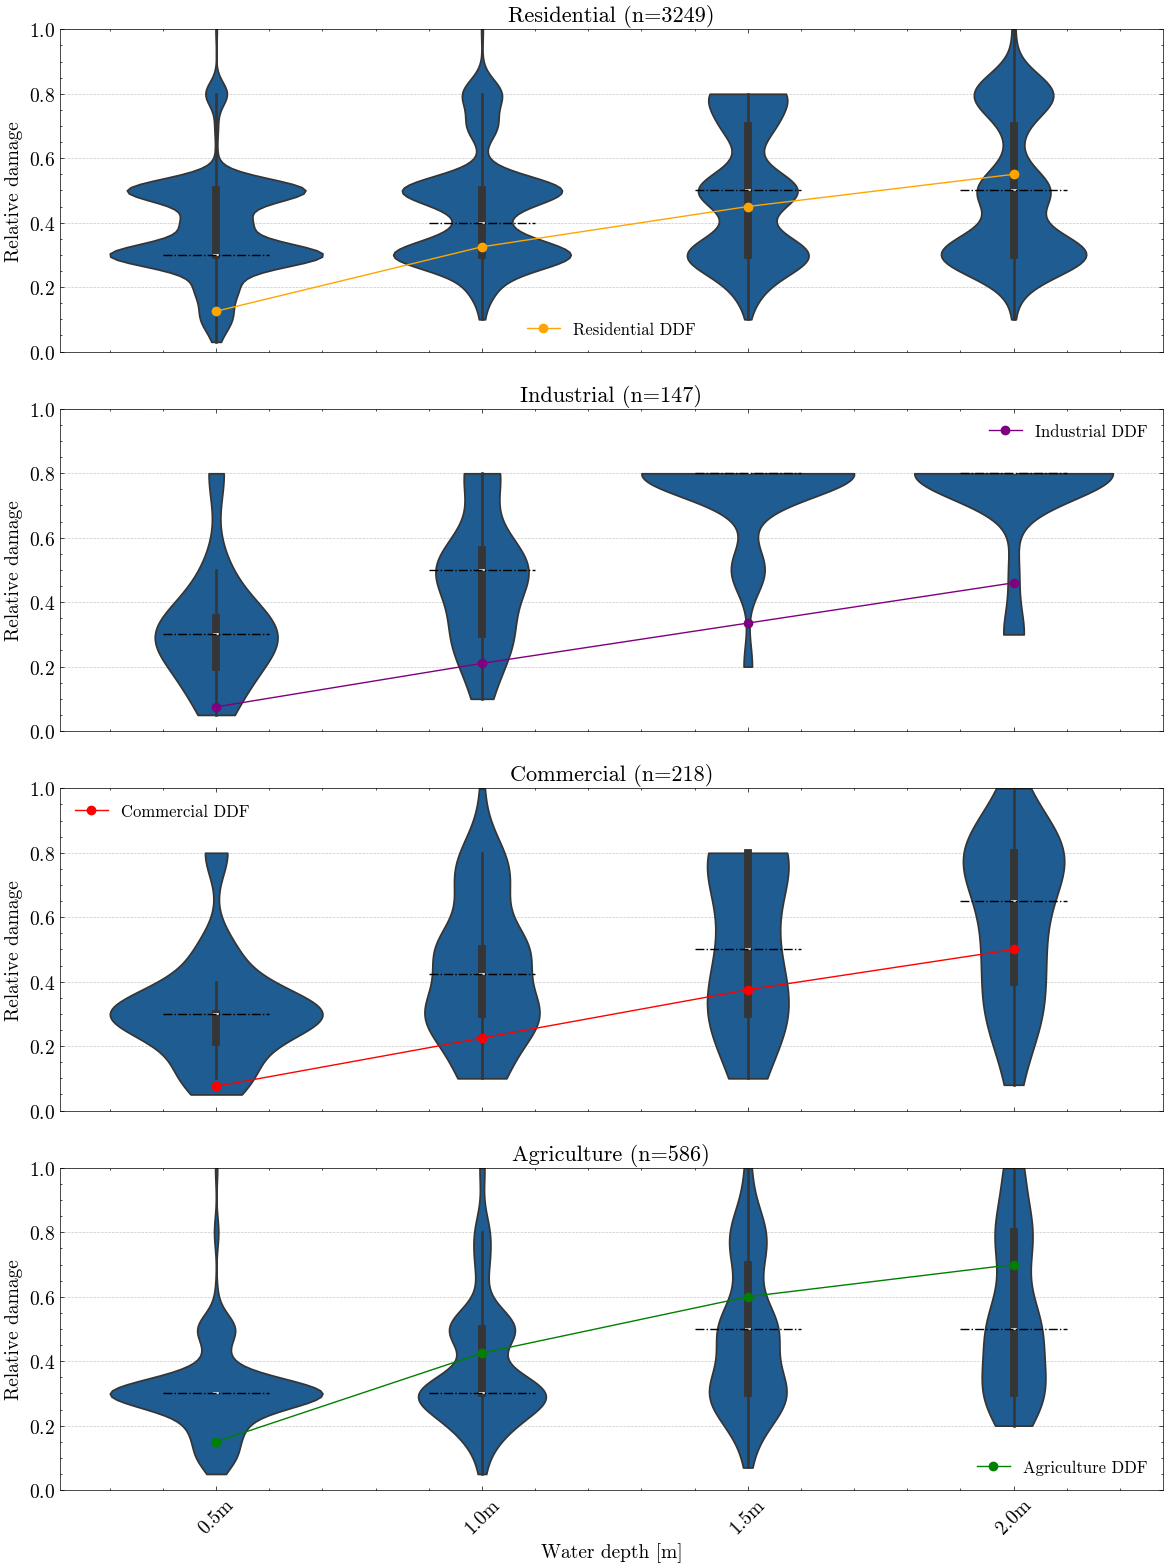

In [44]:
plot_four_property_types_onecol(df, bucket_edges)

# Improving DDF functions - Calibrate for Slovenian Conditions with Train-Test Split

In [45]:
from sklearn.model_selection import train_test_split

# Create stratification column (combination of property_type and water_height_bucket)
df["stratify_col"] = df["property_type"].astype(str) + "_" + df["water_height_bucket"].astype(str)

# Print stratification groups and their counts
print("Stratification groups:")
print(df["stratify_col"].value_counts().sort_index())
print(f"\nTotal samples: {len(df)}")

# Perform train-test split with stratification
# Using 80-20 split, random_state for reproducibility
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["stratify_col"],
    random_state=40
)

print(f"\nTrain set size: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test set size: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Verify stratification worked correctly
print("\nTrain set distribution by property_type:")
print(train_df["property_type"].value_counts())
print("\nTest set distribution by property_type:")
print(test_df["property_type"].value_counts())

# Calibrate damage functions using ONLY the training data
damage_fractions_target = {}
for property_type, damage_function in (
    ("residential", residential_damage_fractions),
    ("industrial", industrial_damage_function),
    ("commercial", commercial_damage_function),
    ("agriculture", agriculture_damage_function),
):
    # Use ONLY training data for calibration
    df_property_train = train_df[train_df["property_type"] == property_type]
    
    _df_grouped = df_property_train.groupby("water_height_bucket", observed=False)["relative_damage"].median().reset_index()
    _df_grouped.columns = ["water_height_bucket", "median_relative_damage"]
    _df_grouped.rename(columns={"water_height_bucket": "depth"}, inplace=True)
    _df_grouped["depth"] = _df_grouped["depth"].str.split("-").str[1].str.replace("m", "").astype(float)
    list_of_tuples = _df_grouped.to_dict(orient="records")
    list_of_tuples = [(0, 0)] + [(t["depth"], t["median_relative_damage"]) for t in list_of_tuples]
    
    print(f"\n{property_type} (trained on n={len(df_property_train)}):")
    print(list_of_tuples) 
    damage_fractions_target[property_type] = list_of_tuples

Stratification groups:
stratify_col
agriculture_0.0-0.5m     165
agriculture_0.5-1.0m     213
agriculture_1.0-1.5m     100
agriculture_1.5-2.0m      68
agriculture_nan           40
commercial_0.0-0.5m       66
commercial_0.5-1.0m       82
commercial_1.0-1.5m       22
commercial_1.5-2.0m       23
commercial_nan            25
industrial_0.0-0.5m       27
industrial_0.5-1.0m       48
industrial_1.0-1.5m       31
industrial_1.5-2.0m       23
industrial_nan            18
residential_0.0-0.5m    1269
residential_0.5-1.0m     801
residential_1.0-1.5m     506
residential_1.5-2.0m     383
residential_nan          290
Name: count, dtype: int64

Total samples: 4200

Train set size: 3360 (80.0%)
Test set size: 840 (20.0%)

Train set distribution by property_type:
property_type
residential    2600
agriculture     468
commercial      175
industrial      117
Name: count, dtype: int64

Test set distribution by property_type:
property_type
residential    649
agriculture    118
commercial      43
indust

## Evaluate Train-Test Split Distribution

Verify that the stratified split maintains the proportions across both property types and water height buckets.


In [46]:
# Create detailed comparison of train/test split
print("Train vs Test Distribution by Stratification Group:")
print("=" * 80)

train_counts = train_df["stratify_col"].value_counts().sort_index()
test_counts = test_df["stratify_col"].value_counts().sort_index()
total_counts = df["stratify_col"].value_counts().sort_index()

comparison_df = pd.DataFrame({
    "Total": total_counts,
    "Train": train_counts,
    "Test": test_counts,
    "Train %": (train_counts / total_counts * 100).round(1),
    "Test %": (test_counts / total_counts * 100).round(1)
})

print(comparison_df)
print("\n✓ Stratification successful if Train % ≈ 80% and Test % ≈ 20% for all groups")


Train vs Test Distribution by Stratification Group:
                      Total  Train  Test  Train %  Test %
stratify_col                                             
agriculture_0.0-0.5m    165    132    33     80.0    20.0
agriculture_0.5-1.0m    213    170    43     79.8    20.2
agriculture_1.0-1.5m    100     80    20     80.0    20.0
agriculture_1.5-2.0m     68     54    14     79.4    20.6
agriculture_nan          40     32     8     80.0    20.0
commercial_0.0-0.5m      66     53    13     80.3    19.7
commercial_0.5-1.0m      82     66    16     80.5    19.5
commercial_1.0-1.5m      22     18     4     81.8    18.2
commercial_1.5-2.0m      23     18     5     78.3    21.7
commercial_nan           25     20     5     80.0    20.0
industrial_0.0-0.5m      27     22     5     81.5    18.5
industrial_0.5-1.0m      48     38    10     79.2    20.8
industrial_1.0-1.5m      31     25     6     80.6    19.4
industrial_1.5-2.0m      23     18     5     78.3    21.7
industrial_nan      

Residential polynomial:
  0.067x^3 - 0.171x^2 + 0.183x 0.426
Industrial polynomial:
  - 0.133x^3 - 0.129x^2 + 0.533x 0.539
Commercial polynomial:
  0.320x^3 - 0.054x^2 + 0.020x 0.388
Agriculture polynomial:
  0.067x^3 - 0.114x^2 + 0.183x 0.377


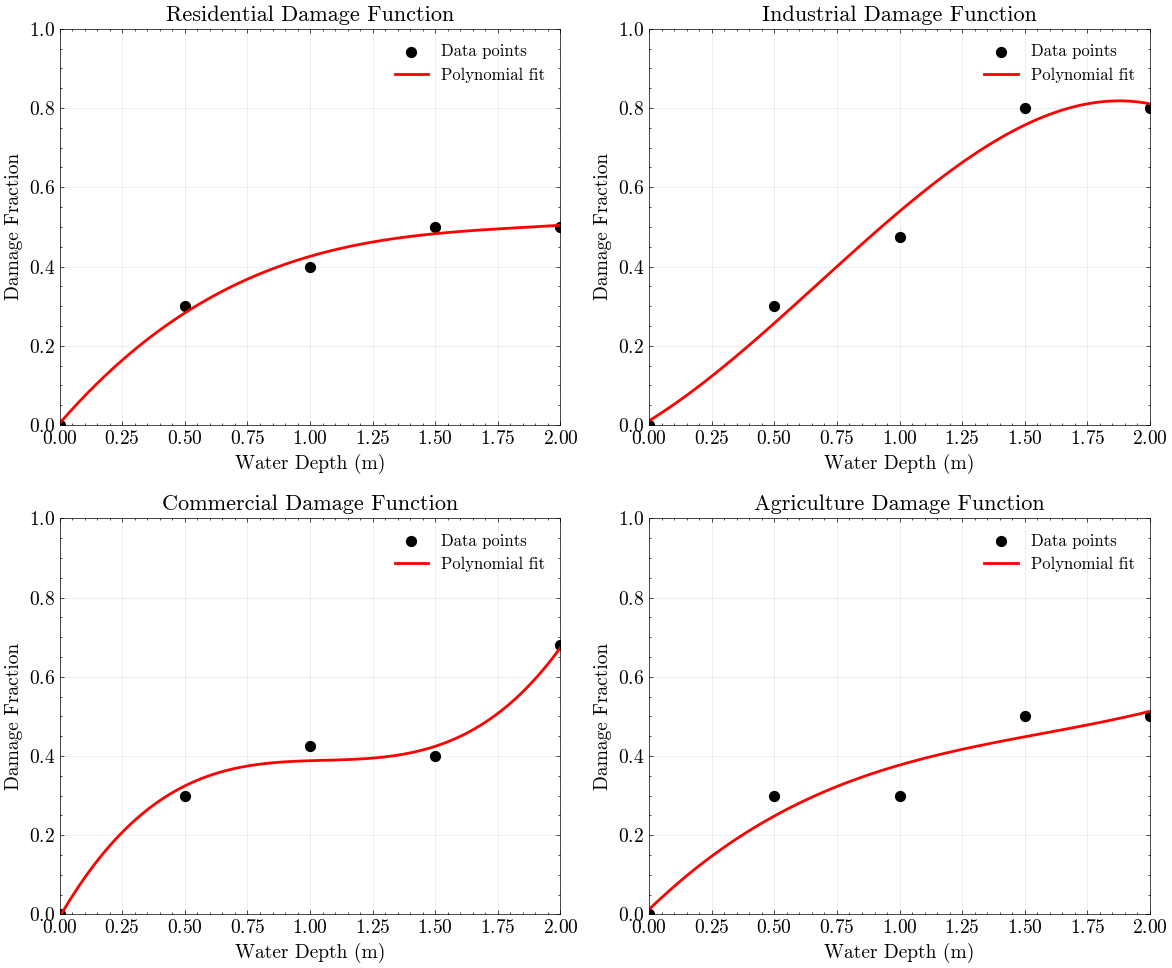

In [47]:
# Fit a polynomial to the target damage fractions
from numpy.polynomial import Polynomial

def format_polynomial_string(poly):
    """Format polynomial string for display on chart."""
    coeffs = poly.coef
    terms = []
    
    for i, coeff in enumerate(coeffs):
        if abs(coeff) < 1e-10:  # Skip very small coefficients
            continue
            
        if i == 0:
            if coeff >= 0:
                terms.append(f"{coeff:.3f}")
            else:
                terms.append(f"- {abs(coeff):.3f}")
        elif i == 1:
            if coeff >= 0:
                terms.append(f"+ {coeff:.3f}x")
            else:
                terms.append(f"- {abs(coeff):.3f}x")
        # Check if last term
        elif i == len(coeffs) - 1:
            if coeff >= 0:
                terms.append(f"{coeff:.3f}x^{i}")
            else:
                terms.append(f"- {abs(coeff):.3f}x^{i}")
        else:
            if coeff >= 0:
                terms.append(f"+ {coeff:.3f}x^{i}")
            else:
                terms.append(f"- {abs(coeff):.3f}x^{i}")
    
    return " ".join(terms[::-1])


def polynomial_fit(data_points, degree=3):
    """
    Fit a polynomial to the given data points.
    
    Args:
        data_points: List of tuples (depth, damage_fraction)
        degree: Degree of polynomial (default: 3)
    
    Returns:
        poly: Polynomial object
        x_fit: Array of x values for plotting
        y_fit: Array of fitted y values
    """
    # Extract x and y values
    x_data = np.array([point[0] for point in data_points])
    y_data = np.array([point[1] for point in data_points])
    
    # Fit polynomial
    poly = Polynomial.fit(x_data, y_data, degree)
    
    # Create smooth curve for plotting
    x_fit = np.linspace(0, 2, 100)
    y_fit = poly(x_fit)
    
    return poly, x_fit, y_fit

# Create polynomial functions for each property type
calibrated_polynomial_functions = {}

property_types = [
    "residential",
    "industrial",
    "commercial",
    "agriculture"
]

for prop_type in property_types:
    data_points = damage_fractions_target[prop_type]
    poly, _, _ = polynomial_fit(data_points, degree=3)
    calibrated_polynomial_functions[prop_type] = poly
    
    print(f"{prop_type.capitalize()} polynomial:")
    print(f"  {format_polynomial_string(poly)}")

# Plot the polynomial fits
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, prop_type in enumerate(property_types):
    data_points = damage_fractions_target[prop_type]
    ax = axes[i]
    
    # Original data points
    x_orig = [point[0] for point in data_points]
    y_orig = [point[1] for point in data_points]
    
    # Polynomial fit
    poly = calibrated_polynomial_functions[prop_type]
    x_fit = np.linspace(0, 2, 100)
    y_fit = poly(x_fit)
    
    # Plot
    ax.scatter(x_orig, y_orig, color='black', s=50, label='Data points')
    ax.plot(x_fit, y_fit, color='red', linewidth=2, label='Polynomial fit')
    
    ax.set_xlabel('Water Depth (m)')
    ax.set_ylabel('Damage Fraction')
    ax.set_title(f'{prop_type.capitalize()} Damage Function')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## LaTeX-Ready Polynomial Coefficients for Thesis

Output formatted for direct copy-paste into LaTeX table.


In [48]:
def format_polynomial_for_latex(poly):
    """
    Format polynomial coefficients for LaTeX table.
    Returns a string in format: ax^3 + bx^2 + cx + d
    """
    coeffs = poly.coef
    # Coefficients are [c0, c1, c2, c3] for c0 + c1*x + c2*x^2 + c3*x^3
    c0, c1, c2, c3 = coeffs[0], coeffs[1], coeffs[2], coeffs[3]
    
    terms = []
    
    # x^3 term
    if c3 >= 0:
        terms.append(f"${c3:.3f}x^3")
    else:
        terms.append(f"$-{abs(c3):.3f}x^3")
    
    # x^2 term
    if c2 >= 0:
        terms.append(f" + {c2:.3f}x^2")
    else:
        terms.append(f" - {abs(c2):.3f}x^2")
    
    # x term
    if c1 >= 0:
        terms.append(f" + {c1:.3f}x")
    else:
        terms.append(f" - {abs(c1):.3f}x")
    
    # constant term
    if c0 >= 0:
        terms.append(f" + {c0:.3f}$")
    else:
        terms.append(f" - {abs(c0):.3f}$")
    
    return "".join(terms)

print("=" * 80)
print("LATEX TABLE FORMAT - Copy these lines into your thesis table:")
print("=" * 80)
print()

property_type_names = {
    "residential": "Residential",
    "industrial": "Industrial",
    "commercial": "Commercial",
    "agriculture": "Agriculture"
}

for prop_type in ["residential", "industrial", "commercial", "agriculture"]:
    poly = calibrated_polynomial_functions[prop_type]
    latex_formula = format_polynomial_for_latex(poly)
    print(f"        {property_type_names[prop_type]} & {latex_formula} \\\\")

print()
print("=" * 80)
print("SUMMARY - Human-readable format:")
print("=" * 80)
for prop_type in ["residential", "industrial", "commercial", "agriculture"]:
    poly = calibrated_polynomial_functions[prop_type]
    print(f"{property_type_names[prop_type]:12s}: {format_polynomial_string(poly)}")


LATEX TABLE FORMAT - Copy these lines into your thesis table:

        Residential & $0.067x^3 - 0.171x^2 + 0.183x + 0.426$ \\
        Industrial & $-0.133x^3 - 0.129x^2 + 0.533x + 0.539$ \\
        Commercial & $0.320x^3 - 0.054x^2 + 0.020x + 0.388$ \\
        Agriculture & $0.067x^3 - 0.114x^2 + 0.183x + 0.377$ \\

SUMMARY - Human-readable format:
Residential : 0.067x^3 - 0.171x^2 + 0.183x 0.426
Industrial  : - 0.133x^3 - 0.129x^2 + 0.533x 0.539
Commercial  : 0.320x^3 - 0.054x^2 + 0.020x 0.388
Agriculture : 0.067x^3 - 0.114x^2 + 0.183x 0.377


Original font size: 14.0
Median for 0.5m: 0.3
Median for 1.0m: 0.4
Median for 1.5m: 0.5
Median for 2.0m: 0.5
ploted for  residential
---------------
Median for 0.5m: 0.3
Median for 1.0m: 0.5
Median for 1.5m: 0.8
Median for 2.0m: 0.8
ploted for  industrial
---------------
Median for 0.5m: 0.3
Median for 1.0m: 0.42500000000000004
Median for 1.5m: 0.5
Median for 2.0m: 0.65
ploted for  commercial
---------------
Median for 0.5m: 0.3
Median for 1.0m: 0.3
Median for 1.5m: 0.5
Median for 2.0m: 0.5
ploted for  agriculture
---------------


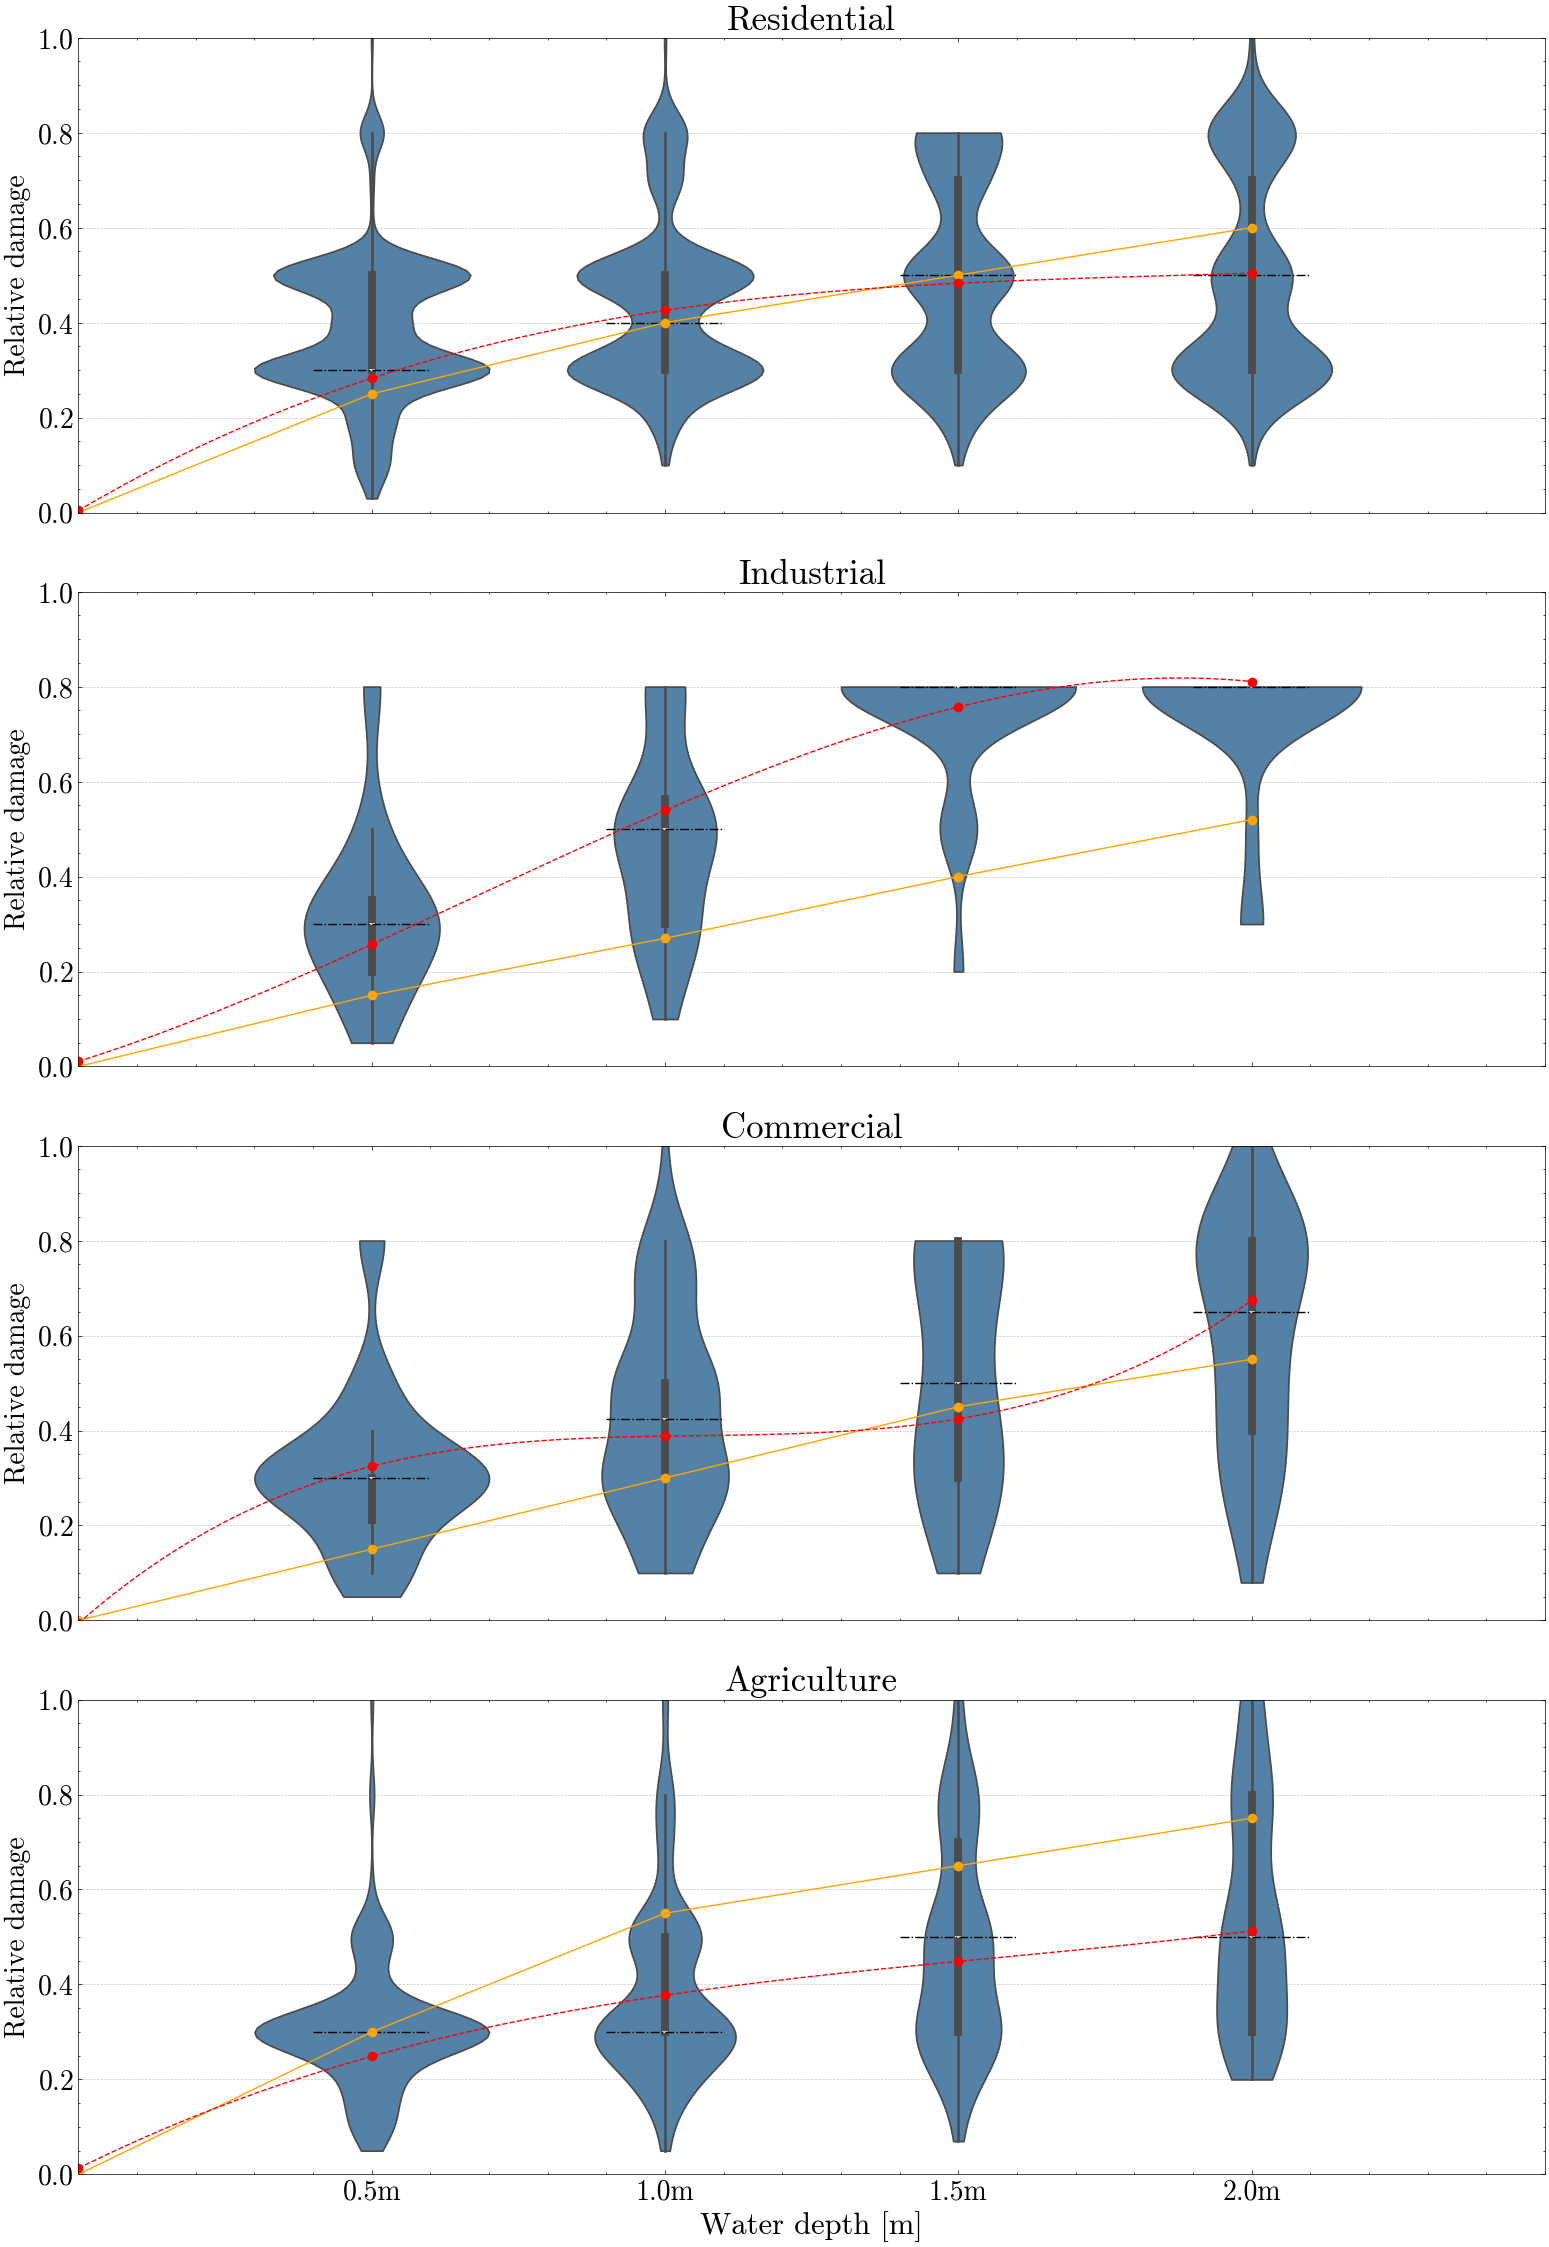

In [53]:
fontsize = 20
sizefactor = 0.8
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(20*sizefactor, 29*sizefactor))

# Increase text font size
original_font_size = plt.rcParams['font.size']
print(f"Original font size: {original_font_size}")

for no, (property_type, damage_function) in enumerate([
    ("residential", residential_damage_fractions,),
    ("industrial", industrial_damage_function,),
    ("commercial", commercial_damage_function,),
    ("agriculture", agriculture_damage_function,),
]):  
    plt.rcParams.update({'font.size': fontsize})
    _df = df.copy()
    _df = _df[_df["property_type"] == property_type]
    
    calibrated_damage_function = calibrated_polynomial_functions[property_type]

    ax = axes[no]
    
    # _df = _df[_df["Objekt_VrstaObjektaId"].isin(vrste_objekta_id)]
    # plot_violin_damage_by_water_height(_df)
    fig, ax = plot_violin_damage_by_water_height(_df, title="NO", ax=ax)#title=property_type, title="NO")
    fig, ax = plot_damage_function(damage_function, color="orange", label=property_type.capitalize() + " DDF", ax=ax, calibrated_damage_function=calibrated_damage_function)
    
    # ax.legend()
    ax.set_title(property_type.capitalize(), fontsize=fontsize + 5)
    # Hide x-axis ticks
    if no != 3:
        ax.set_xlabel(None)
        ax.set_xticklabels([])
    print("ploted for ", property_type)
    print("---------------")

    # plt.savefig(IMAGES_PATH + f"/05/violin_damage_by_water_height_bucker_{property_type}.pdf", dpi=300, bbox_inches="tight")
    

axes[-1].set_xlabel("Water depth [m]", fontsize=fontsize+2, fontweight="bold")
axes[-1].tick_params(axis="x", labelrotation=0)

# plt.legend()


plt.savefig(IMAGES_PATH + f"/05/violin_damage_by_water_height_bucket_all_calibrated.pdf", dpi=300, bbox_inches="tight")
# plt.show()

plt.rcParams.update({'font.size': original_font_size})

## Predict new relative damages from calibrated functions (Train and Test)

In [144]:
# Calculate predicted damage for TRAIN set (calibrated on this data)
train_df["predicted_relative_damage_calibrated"] = train_df.apply(
    lambda row: calibrated_polynomial_functions[row["property_type"]](row["Objekt_VisinaVodeM"]),
    axis=1
)

# Calculate predicted damage for TEST set (not seen during calibration)
test_df["predicted_relative_damage_calibrated"] = test_df.apply(
    lambda row: calibrated_polynomial_functions[row["property_type"]](row["Objekt_VisinaVodeM"]),
    axis=1
)

print("✓ Calibrated predictions generated for train and test sets")
print(f"Train set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")

✓ Calibrated predictions generated for train and test sets
Train set: 3360 samples
Test set: 840 samples


In [145]:
# Show sample of train data with predictions
print("Train set sample:")
print(train_df[["property_type", "water_height_bucket", "Objekt_VisinaVodeM", "relative_damage", "predicted_relative_damage_calibrated"]].head(10))

print("\nTest set sample:")
print(test_df[["property_type", "water_height_bucket", "Objekt_VisinaVodeM", "relative_damage", "predicted_relative_damage_calibrated"]].head(10))

Train set sample:
      property_type water_height_bucket  Objekt_VisinaVodeM  relative_damage  \
18761   residential            0.5-1.0m                0.62              0.4   
9612    residential            0.5-1.0m                0.70              0.3   
3810    agriculture                 NaN                0.00              1.0   
10194   residential            1.0-1.5m                1.10              0.3   
8423    residential            0.5-1.0m                0.80              0.3   
13557    commercial            0.0-0.5m                0.20              0.3   
10135   residential                 NaN                2.10              0.8   
15144   residential            0.5-1.0m                0.80              0.8   
13298   residential            1.5-2.0m                1.60              0.3   
13630   residential            0.5-1.0m                0.70              0.5   

       predicted_relative_damage_calibrated  
18761                              0.327635  
9612     

### Performance measures for calibrated functions - TRAIN SET vs TEST SET

In [146]:
print("=" * 80)
print("TRAIN SET PERFORMANCE (model calibrated on this data)")
print("=" * 80)

# Calculate error metrics for TRAIN dataset
bucket_stats_train = calculate_error_metrics_by_depth_bucket(
    train_df, predicted_column="predicted_relative_damage_calibrated"
)

# Display results
print("\nError Metrics by Depth Bucket - TRAIN:")
print("-" * 80)
print(f"{'Bucket':>12} {'ME':>8} {'RMSE':>6} | {'n':>5} {'Obs':>6} {'Pred':>6}")
print("-" * 80)
for bucket in bucket_stats_train:
    stats = bucket_stats_train[bucket]
    print(f"{bucket:>12}: {stats['me']:+.3f} {stats['rmse']:>6.3f} | "
          f"{stats['count']:>5} {stats['mean_observed']:>6.3f} {stats['mean_predicted']:>6.3f}")

# Calculate overall statistics for train
overall_me_train = np.mean([stats['me'] for stats in bucket_stats_train.values()])
overall_rmse_train = np.mean([stats['rmse'] for stats in bucket_stats_train.values()])
total_observations_train = sum(stats['count'] for stats in bucket_stats_train.values())

print(f"\nTrain Overall ME: {overall_me_train:+.3f}")
print(f"Train Overall RMSE: {overall_rmse_train:.3f}")
print(f"Train observations: {total_observations_train} / {len(train_df)} ({total_observations_train/len(train_df)*100:.1f}%)")

print("\n" + "=" * 80)
print("TEST SET PERFORMANCE (model evaluated on unseen data)")
print("=" * 80)

# Calculate error metrics for TEST dataset
bucket_stats_test = calculate_error_metrics_by_depth_bucket(
    test_df, predicted_column="predicted_relative_damage_calibrated"
)

# Display results
print("\nError Metrics by Depth Bucket - TEST:")
print("-" * 80)
print(f"{'Bucket':>12} {'ME':>8} {'RMSE':>6} | {'n':>5} {'Obs':>6} {'Pred':>6}")
print("-" * 80)
for bucket in bucket_stats_test:
    stats = bucket_stats_test[bucket]
    print(f"{bucket:>12}: {stats['me']:+.3f} {stats['rmse']:>6.3f} | "
          f"{stats['count']:>5} {stats['mean_observed']:>6.3f} {stats['mean_predicted']:>6.3f}")

# Calculate overall statistics for test
overall_me_test = np.mean([stats['me'] for stats in bucket_stats_test.values()])
overall_rmse_test = np.mean([stats['rmse'] for stats in bucket_stats_test.values()])
total_observations_test = sum(stats['count'] for stats in bucket_stats_test.values())

print(f"\nTest Overall ME: {overall_me_test:+.3f}")
print(f"Test Overall RMSE: {overall_rmse_test:.3f}")
print(f"Test observations: {total_observations_test} / {len(test_df)} ({total_observations_test/len(test_df)*100:.1f}%)")

print("\n" + "=" * 80)
print("COMPARISON: Train vs Test")
print("=" * 80)
print(f"ME difference (Test - Train): {overall_me_test - overall_me_train:+.3f}")
print(f"RMSE difference (Test - Train): {overall_rmse_test - overall_rmse_train:+.3f}")
print("\n✓ Small differences indicate good generalization (no overfitting)")
print("✓ Large positive RMSE difference suggests overfitting to training data")


TRAIN SET PERFORMANCE (model calibrated on this data)

Error Metrics by Depth Bucket - TRAIN:
--------------------------------------------------------------------------------
      Bucket       ME   RMSE |     n    Obs   Pred
--------------------------------------------------------------------------------
    0.0-0.5m: -0.165  0.229 |  1222  0.364  0.199
    0.5-1.0m: -0.056  0.188 |   915  0.428  0.372
    1.0-1.5m: -0.030  0.204 |   528  0.498  0.468
    1.5-2.0m: +0.005  0.218 |   397  0.509  0.514

Train Overall ME: -0.061
Train Overall RMSE: 0.210
Train observations: 3062 / 3360 (91.1%)

TEST SET PERFORMANCE (model evaluated on unseen data)

Error Metrics by Depth Bucket - TEST:
--------------------------------------------------------------------------------
      Bucket       ME   RMSE |     n    Obs   Pred
--------------------------------------------------------------------------------
    0.0-0.5m: -0.172  0.241 |   305  0.368  0.196
    0.5-1.0m: -0.054  0.171 |   229  0.427  

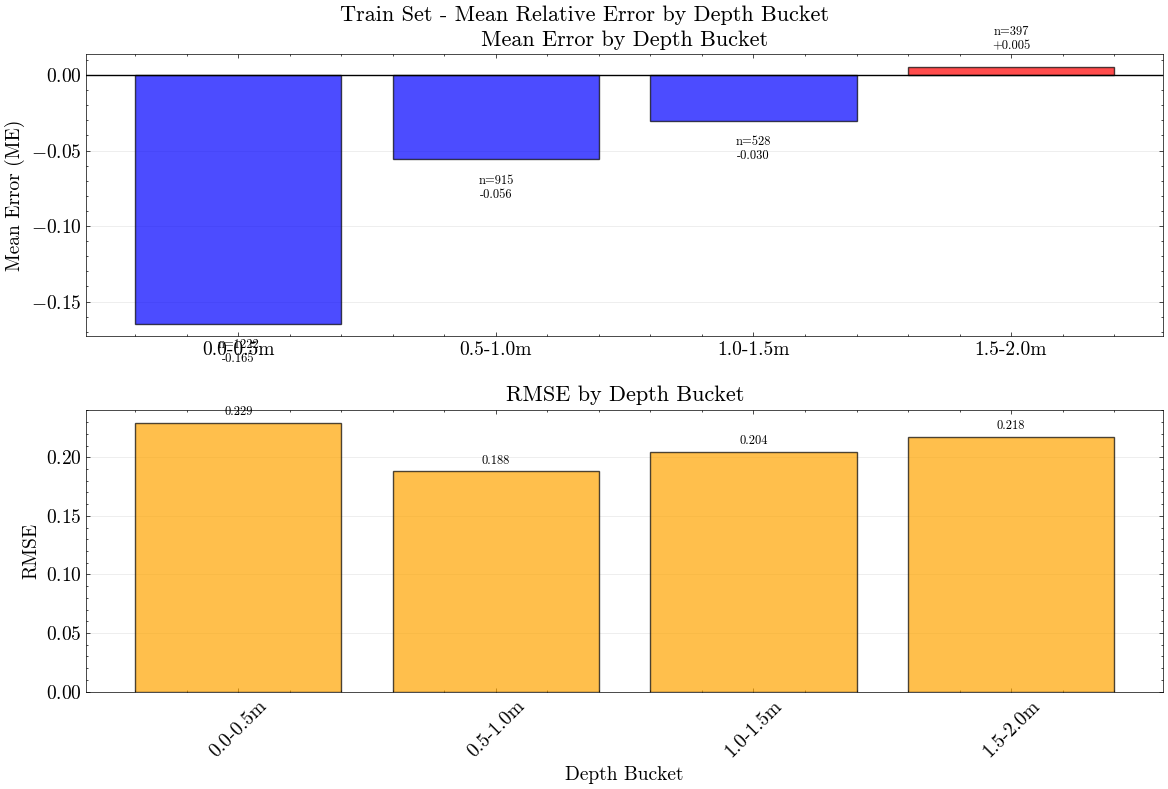

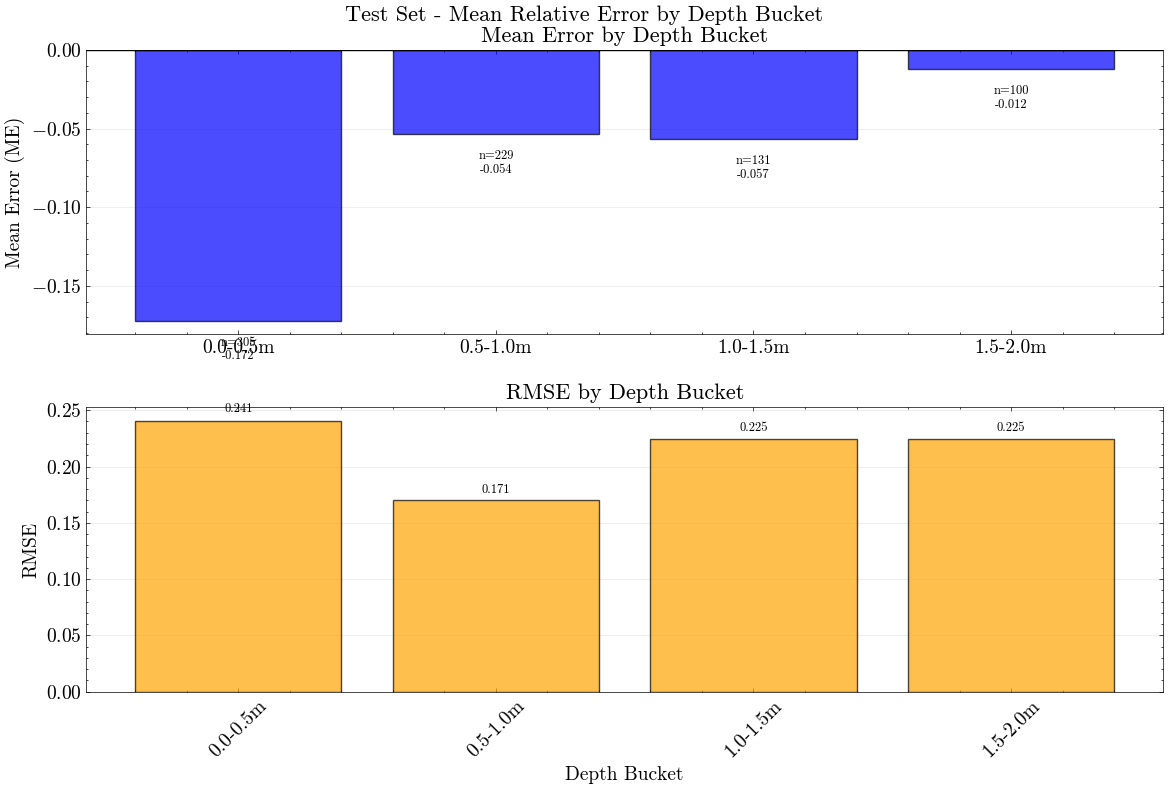

In [147]:
# Plot MREb visualization for both Train and Test
fig_train = plot_error_metrics_by_depth_bucket(bucket_stats_train)
plt.suptitle("Train Set - Mean Relative Error by Depth Bucket", fontsize=16, y=1.00)
# plt.savefig(IMAGES_PATH + "/05/mre_by_depth_bucket_train.pdf", dpi=300, bbox_inches="tight")
plt.show()

fig_test = plot_error_metrics_by_depth_bucket(bucket_stats_test)
plt.suptitle("Test Set - Mean Relative Error by Depth Bucket", fontsize=16, y=1.00)
# plt.savefig(IMAGES_PATH + "/05/mre_by_depth_bucket_test.pdf", dpi=300, bbox_inches="tight")
plt.show()


### Analysis by Building Type - TEST SET Performance

Evaluate calibrated model performance by property type on the test set (unseen data).


In [148]:
# Define building type mappings
property_types = [
    "residential",
    "industrial",
    "commercial",
    "agriculture",
]

print("=" * 80)
print("Analysis by Building Type - TEST SET")
print("=" * 80)

# Store results for comparison (TEST SET)
building_type_results_test = {}

for property_type in property_types:
    # Filter TEST data for this building type
    type_df_test = test_df[test_df["property_type"] == property_type]
    
    if len(type_df_test) < 5:  # Skip if too few samples
        print(f"\n{property_type}: Insufficient test data (n={len(type_df_test)})")
        continue
    
    print(f"\n{property_type}:")
    print(f"Test sample size: {len(type_df_test)}")
    
    # Calculate error metrics for this building type on TEST set
    bucket_stats_type = calculate_error_metrics_by_depth_bucket(
        type_df_test,
        predicted_column="predicted_relative_damage_calibrated"
    )
    
    # Calculate Spearman correlation
    correlation_type, p_value_type = calculate_spearman_correlation(
        type_df_test,
    )
    
    # Calculate overall metrics
    if bucket_stats_type:
        all_mes = [bucket_stats_type[bucket]["me"] for bucket in bucket_stats_type]
        overall_me_type = np.mean(all_mes)
        all_rmses = [bucket_stats_type[bucket]["rmse"] for bucket in bucket_stats_type]
        overall_rmse_type = np.mean(all_rmses)
        print(f"Overall ME: {overall_me_type:+.3f}")
        print(f"Overall RMSE: {overall_rmse_type:.3f}")
    else:
        overall_me_type = overall_rmse_type = None
        print("No data in depth buckets")
    
    print(f"Spearman ρs: {correlation_type:.4f} (p = {p_value_type:.2e})")
    
    # Store results
    building_type_results_test[property_type] = {
        "sample_size": len(type_df_test),
        "overall_me": overall_me_type,
        "overall_rmse": overall_rmse_type,
        "spearman_correlation": correlation_type,
        "spearman_p_value": p_value_type,
        "bucket_stats": bucket_stats_type,
    }


Analysis by Building Type - TEST SET

residential:
Test sample size: 649
Overall ME: -0.073
Overall RMSE: 0.217
Spearman ρs: 0.2501 (p = 1.03e-10)

industrial:
Test sample size: 30
Overall ME: -0.059
Overall RMSE: 0.101
Spearman ρs: 0.5386 (p = 2.14e-03)

commercial:
Test sample size: 43
Overall ME: -0.126
Overall RMSE: 0.262
Spearman ρs: 0.5111 (p = 4.61e-04)

agriculture:
Test sample size: 118
Overall ME: -0.063
Overall RMSE: 0.195
Spearman ρs: 0.3589 (p = 6.57e-05)


In [ ]:
# Create summary table of TEST results
print("\n\nSummary Table - TEST SET Performance:")
print("=" * 90)
print(f"{'Building Type':<20} {'Test Size':<12} {'ME':<10} {'RMSE':<8} {'Spearman ρs':<12} {'P-value':<10}")
print("-" * 90)

for type_name, results in building_type_results_test.items():
    me_str = f"{results['overall_me']:+.3f}" if results['overall_me'] is not None else "N/A"
    rmse_str = f"{results['overall_rmse']:.3f}" if results['overall_rmse'] is not None else "N/A"
    print(
        f"{type_name:<20} {results['sample_size']:<12} {me_str:<10} {rmse_str:<8} "
        f"{results['spearman_correlation']:<12.4f} {results['spearman_p_value']:<10.2e}"
    )

# Overall test results
print("-" * 90)
print(
    f"{'Overall (Test)':<20} {len(test_df):<12} {overall_me_test:<10.3f} {overall_rmse_test:<8.3f}"
)
print("\n✓ These metrics represent model performance on UNSEEN data (test set)")




Summary Table - TEST SET Performance:
Building Type        Test Size    ME         RMSE     Spearman ρs  P-value   
------------------------------------------------------------------------------------------
residential          649          -0.073     0.217    0.2501       1.03e-10  
industrial           30           -0.059     0.101    0.5386       2.14e-03  
commercial           43           -0.126     0.262    0.5111       4.61e-04  
agriculture          118          -0.063     0.195    0.3589       6.57e-05  
------------------------------------------------------------------------------------------
Overall (Test)       840          -0.074     0.215   

✓ These metrics represent model performance on UNSEEN data (test set)
